In [1]:
import pypsa
import numpy as np
import pandas as pd
import xarray as xr
import atlite
import yaml
import sys
from pathlib import Path
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import math

# directory set up on cluster

# root = Path.cwd()
# pypsa_eur_root = root  
# home_root = root.parent        

# pypsa_dmg_root = home_root / "pypsa-damage"
# pypsa_eur_scripts = pypsa_eur_root / "scripts"

# sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

# directory set up on local machine
root = Path.cwd()
pypsa_eur_root = root.parent.parent  
home_root = pypsa_eur_root.parent        

pypsa_dmg_root = home_root / "pypsa-damage"
pypsa_eur_scripts = pypsa_eur_root / "scripts"

sys.path.insert(0, str(pypsa_eur_root))
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

In [2]:
sys.path

['/home/lois/pypsa-eur/pypsa-eur/scripts/_testing',
 '/home/lois/pypsa-eur/pypsa-eur/scripts',
 '/home/lois/pypsa-eur/pypsa-eur',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python313.zip',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/lib-dynload',
 '',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages']

### Config name

In [3]:
# ===========================================================================
# CONFIGURATION — edit here
# ===========================================================================
CONFIG_NAME  = "10years-FR"
YEARS        = list(range(2014, 2023))   # 2014–2022
YEAR         = 2022                       # pick one to inspect
CLUSTERS     = 5
CF_ACTUAL_DIR     = pypsa_dmg_root / "entsoe_comparison/outputs"
CF_ACTUAL_PATTERN = "cf_B14_plant_{year}-01-01_{year}-12-31.csv"
cf_fixed_factor   = 0.616

CUTOUT_PATH = pypsa_eur_root / "data/cutout/build/unknown" / f"europe-{YEAR}-era5_fg10_lmlt.nc"

_results = pypsa_eur_root / "results" / CONFIG_NAME

SCENARIO_VARIANTS = {
    "cap": f"weather_year_{YEAR}_nuc_cap",
    "dis": f"weather_year_{YEAR}_nuc_dis",
}

NETWORK_PATHS = {
    "base_cap": _results / f"weather_year_{YEAR}_nuc_base" / "networks" / "base_s_5_elec_.nc",
    "base_dis": _results / f"weather_year_{YEAR}_nuc_base" / "networks" / "base_s_5_elec__op.nc",
    "cap":      _results / f"weather_year_{YEAR}_nuc_cap"  / "networks" / "base_s_5_elec_.nc",
    "dis":      _results / f"weather_year_{YEAR}_nuc_dis"  / "networks" / "base_s_5_elec__damaged-dispatch.nc",
}



In [4]:
DIS_NETWORK_PATHS = {
    year: _results / f"weather_year_{year}_nuc_dis" / "networks" / "base_s_5_elec__damaged-dispatch.nc"
    for year in YEARS
}
DIS_NETWORK_PATHS

{2014: PosixPath('/home/lois/pypsa-eur/pypsa-eur/results/10years-FR/weather_year_2014_nuc_dis/networks/base_s_5_elec__damaged-dispatch.nc'),
 2015: PosixPath('/home/lois/pypsa-eur/pypsa-eur/results/10years-FR/weather_year_2015_nuc_dis/networks/base_s_5_elec__damaged-dispatch.nc'),
 2016: PosixPath('/home/lois/pypsa-eur/pypsa-eur/results/10years-FR/weather_year_2016_nuc_dis/networks/base_s_5_elec__damaged-dispatch.nc'),
 2017: PosixPath('/home/lois/pypsa-eur/pypsa-eur/results/10years-FR/weather_year_2017_nuc_dis/networks/base_s_5_elec__damaged-dispatch.nc'),
 2018: PosixPath('/home/lois/pypsa-eur/pypsa-eur/results/10years-FR/weather_year_2018_nuc_dis/networks/base_s_5_elec__damaged-dispatch.nc'),
 2019: PosixPath('/home/lois/pypsa-eur/pypsa-eur/results/10years-FR/weather_year_2019_nuc_dis/networks/base_s_5_elec__damaged-dispatch.nc'),
 2020: PosixPath('/home/lois/pypsa-eur/pypsa-eur/results/10years-FR/weather_year_2020_nuc_dis/networks/base_s_5_elec__damaged-dispatch.nc'),
 2021: PosixP

In [5]:
# ===========================================================================
# Helpers
# ===========================================================================
def _base_name(name: str) -> str:
    return re.sub(r"\s+\d+$", "", name.strip().upper())


def _build_mapping(powerplants_df: pd.DataFrame, cf_actual: pd.DataFrame) -> pd.DataFrame:
    unit_names = cf_actual.unit_name.unique()
    rows = []
    for pp_name in powerplants_df["Name"]:
        base    = _base_name(pp_name)
        matched = [u for u in unit_names if u.startswith(base)]
        for unit in matched:
            rows.append({"Name": pp_name, "unit_name": unit})
    return pd.DataFrame(rows).sort_values("Name").reset_index(drop=True)

from scripts.build_damage_profiles.build_nuclear_damage_profiles import load_nuclear_plants


def load_scenario(scenario_dir: Path) -> dict:
    year_match = re.search(r"weather_year_(\d+)_", scenario_dir.name)
    year = int(year_match.group(1)) if year_match else YEAR

    powerplants_df = load_nuclear_plants(scenario_dir / f"powerplants_s_{CLUSTERS}.csv", dateout_cutoff= 2017)

    damage_df = xr.open_dataset(
        scenario_dir / "damage_profiles" / "nuclear_damage_plants.nc"
    )["profile"].to_pandas()
    damage_df.index = pd.to_datetime(damage_df.index)

    # cf_actual = pd.read_csv(
    #     CF_ACTUAL_DIR / CF_ACTUAL_PATTERN.format(year=year),
    #     index_col=0, parse_dates=True,
    # )
    # mapping = _build_mapping(powerplants_df, cf_actual)

    return {
        "year":           year,
        "scenario_dir":   scenario_dir,
        "damage_df":      damage_df,
        "powerplants_df": powerplants_df
    }


In [6]:
_resources = pypsa_eur_root / "resources" / CONFIG_NAME

scenarios_dis = {
    year: load_scenario(_resources / f"weather_year_{year}_nuc_dis")
    for year in YEARS
}
scenarios_cap = {
    year: load_scenario(_resources / f"weather_year_{year}_nuc_cap")
    for year in YEARS
}


In [8]:
scenarios_dis

{2014: {'year': 2014,
  'scenario_dir': PosixPath('/home/lois/pypsa-eur/pypsa-eur/resources/10years-FR/weather_year_2014_nuc_dis'),
  'damage_df': plant                Nogent  Paluel 2  Penly 3  St Alban  Tricastin 2  \
  time                                                                    
  2014-06-01 00:00:00     0.0       0.0      0.0       0.0          0.0   
  2014-06-01 01:00:00     0.0       0.0      0.0       0.0          0.0   
  2014-06-01 02:00:00     0.0       0.0      0.0       0.0          0.0   
  2014-06-01 03:00:00     0.0       0.0      0.0       0.0          0.0   
  2014-06-01 04:00:00     0.0       0.0      0.0       0.0          0.0   
  ...                     ...       ...      ...       ...          ...   
  2015-05-31 19:00:00     0.0       0.0      0.0       0.0          0.0   
  2015-05-31 20:00:00     0.0       0.0      0.0       0.0          0.0   
  2015-05-31 21:00:00     0.0       0.0      0.0       0.0          0.0   
  2015-05-31 22:00:00     0.0 

In [7]:
from styles import _DAMAGE_COLORS, _compute_day_ticks

def _bus_availability(bus: str, s: dict) -> pd.Series:
    pp = s["powerplants_df"]
    bus_plants = pp[(pp["bus"] == bus) & (pp["Name"].isin(s["damage_df"].columns))]
    weights = bus_plants["Capacity"].values.astype(float)
    profiles = s["damage_df"][bus_plants["Name"]].values
    return pd.Series(
        1 - np.average(profiles, axis=1, weights=weights),
        index=s["damage_df"].index,
    )


def plot_bus_multiyear(
    bus: str,
    scenarios_dis: dict,
    date_window: tuple = ("06-01", "08-31"),
    figsize=(14, 4),
) -> tuple:
    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.cm.Blues

    for i, (year, s) in enumerate(sorted(scenarios_dis.items())):
        color = cmap(0.3 + 0.7 * i / (len(scenarios_dis) - 1))
        avail = _bus_availability(bus, s)
        avail = avail.loc[f"{year}-{date_window[0]}":f"{year}-{date_window[1]}"]
        x = avail.index.map(lambda t: t.replace(year=2000))
        ax.plot(x, avail.values, label=str(year), linewidth=1.0, color=color)

    tickvals, ticktext = _compute_day_ticks(x)
    ax.set_xticks(tickvals)
    ax.set_xticklabels(ticktext, rotation=90, ha="right", fontsize=8)

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.grid(True, which="major", axis="y", alpha=0.3, linestyle="--")
    ax.set_ylabel("Availability (cap-weighted)")
    ax.set_title(f"Nuclear availability — bus {bus}")
    ax.legend(title="Year", loc="lower right", fontsize=9)
    fig.tight_layout()
    return fig, ax




In [10]:
print(next(iter(scenarios_dis.values()))["powerplants_df"]["bus"].unique())


['FR0 1' 'FR0 3' 'FR0 0' 'FR0 4' 'FR0 2']


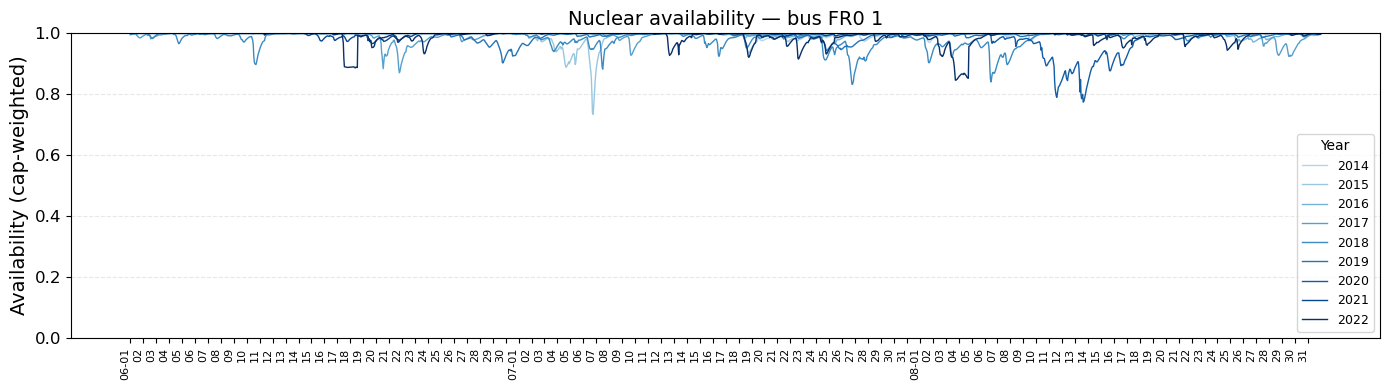

In [11]:
fig, ax = plot_bus_multiyear(
    bus="FR0 1",
    scenarios_dis=scenarios_dis,
    date_window=("06-01", "08-31"),
)
plt.show()


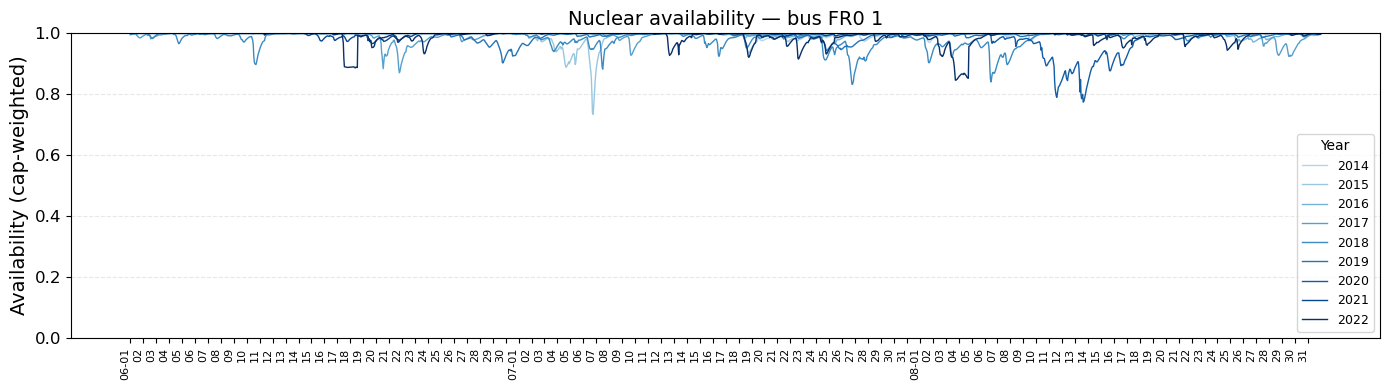

In [ ]:
fig, ax = plot_bus_multiyear(
    bus="FR0 1",
    scenarios_dis=scenarios_dis,
    date_window=("06-01", "08-31"),
)
plt.show()


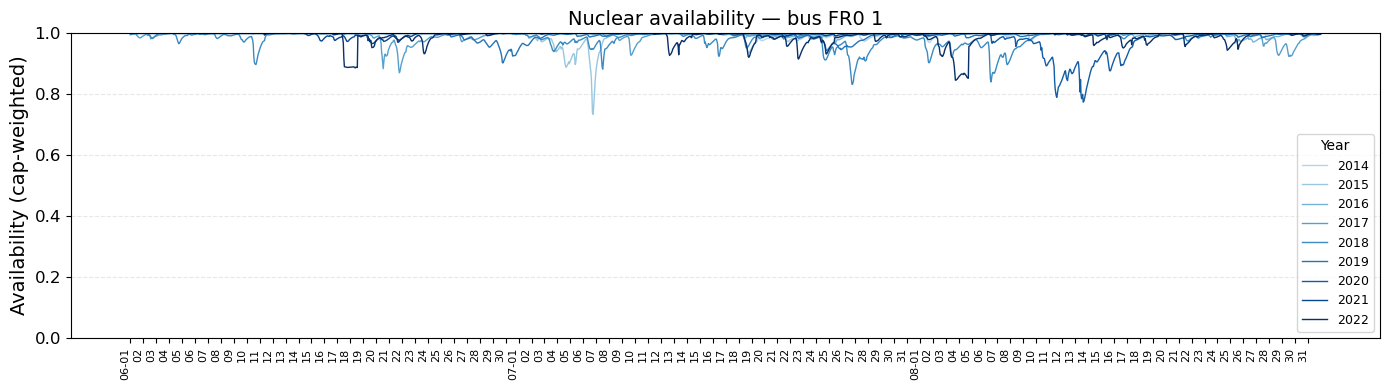

In [172]:
fig, ax = plot_bus_multiyear(
    bus="FR0 1",
    scenarios_dis=scenarios_dis,
    date_window=("06-01", "08-31"),
)
plt.show()


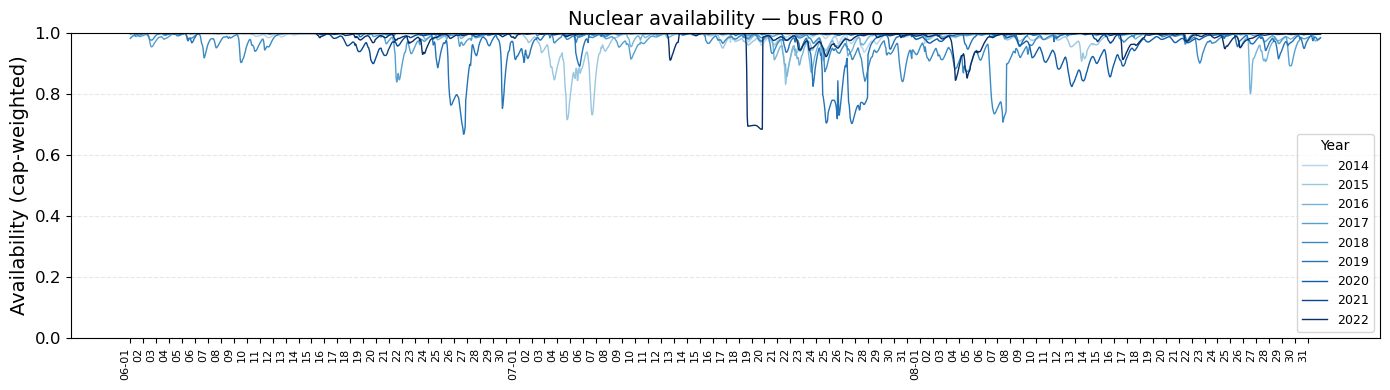

In [173]:
fig, ax = plot_bus_multiyear(
    bus="FR0 0",
    scenarios_dis=scenarios_dis,
    date_window=("06-01", "08-31"),
)
plt.show()


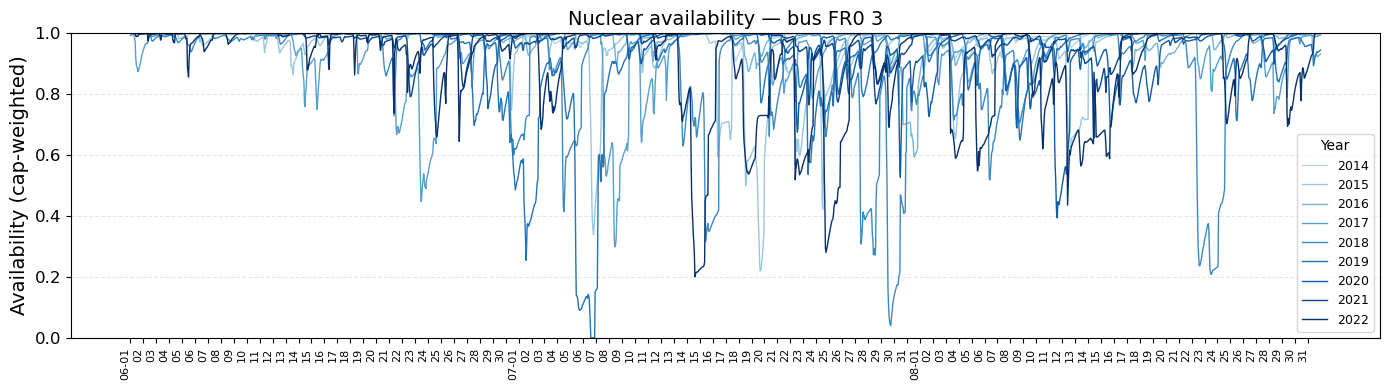

In [59]:
fig, ax = plot_bus_multiyear(
    bus="FR0 3",
    scenarios_dis=scenarios_dis,
    date_window=("06-01", "08-31"),
)
plt.show()


In [12]:
def plot_all_buses_multiyear(
    scenarios_dis: dict,
    date_window: tuple = ("06-01", "08-31"),
    ncols: int = 2,
    figsize_per: tuple = (10, 3),
) -> tuple:
    buses = sorted(
        next(iter(scenarios_dis.values()))["powerplants_df"]["bus"].unique()
    )
    nrows = math.ceil(len(buses) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        sharey=True,
    )
    axes_flat = np.array(axes).flatten()
    cmap = plt.cm.Blues

    for ax, bus in zip(axes_flat, buses):
        for i, (year, s) in enumerate(sorted(scenarios_dis.items())):
            color = cmap(0.3 + 0.7 * i / (len(scenarios_dis) - 1))
            avail = _bus_availability(bus, s)
            avail = avail.loc[f"{year}-{date_window[0]}":f"{year}-{date_window[1]}"]
            x = avail.index.map(lambda t: t.replace(year=2000))
            ax.plot(x, avail.values, label=str(year), linewidth=1.0, color=color)

        tickvals, ticktext = _compute_day_ticks(x)
        ax.set_xticks(tickvals)
        ax.set_xticklabels(ticktext, rotation=90, ha="right", fontsize=7)
        ax.set_ylim(0, 1)
        ax.set_yticks(np.arange(0, 1.2, 0.2))
        ax.grid(True, which="major", axis="y", alpha=0.3, linestyle="--")
        ax.set_title(bus)

    for ax in axes_flat[len(buses):]:
        ax.set_visible(False)

    axes_flat[0].set_ylabel("% Operational Capacity")

    handles = [
        mpatches.Patch(color=cmap(0.3 + 0.7 * i / (len(scenarios_dis) - 1)), label=str(year))
        for i, year in enumerate(sorted(scenarios_dis))
    ]
    fig.legend(handles=handles, title="Year", loc="lower center",
               ncol=len(scenarios_dis), bbox_to_anchor=(0.5, 0), frameon=False)
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    return fig, axes


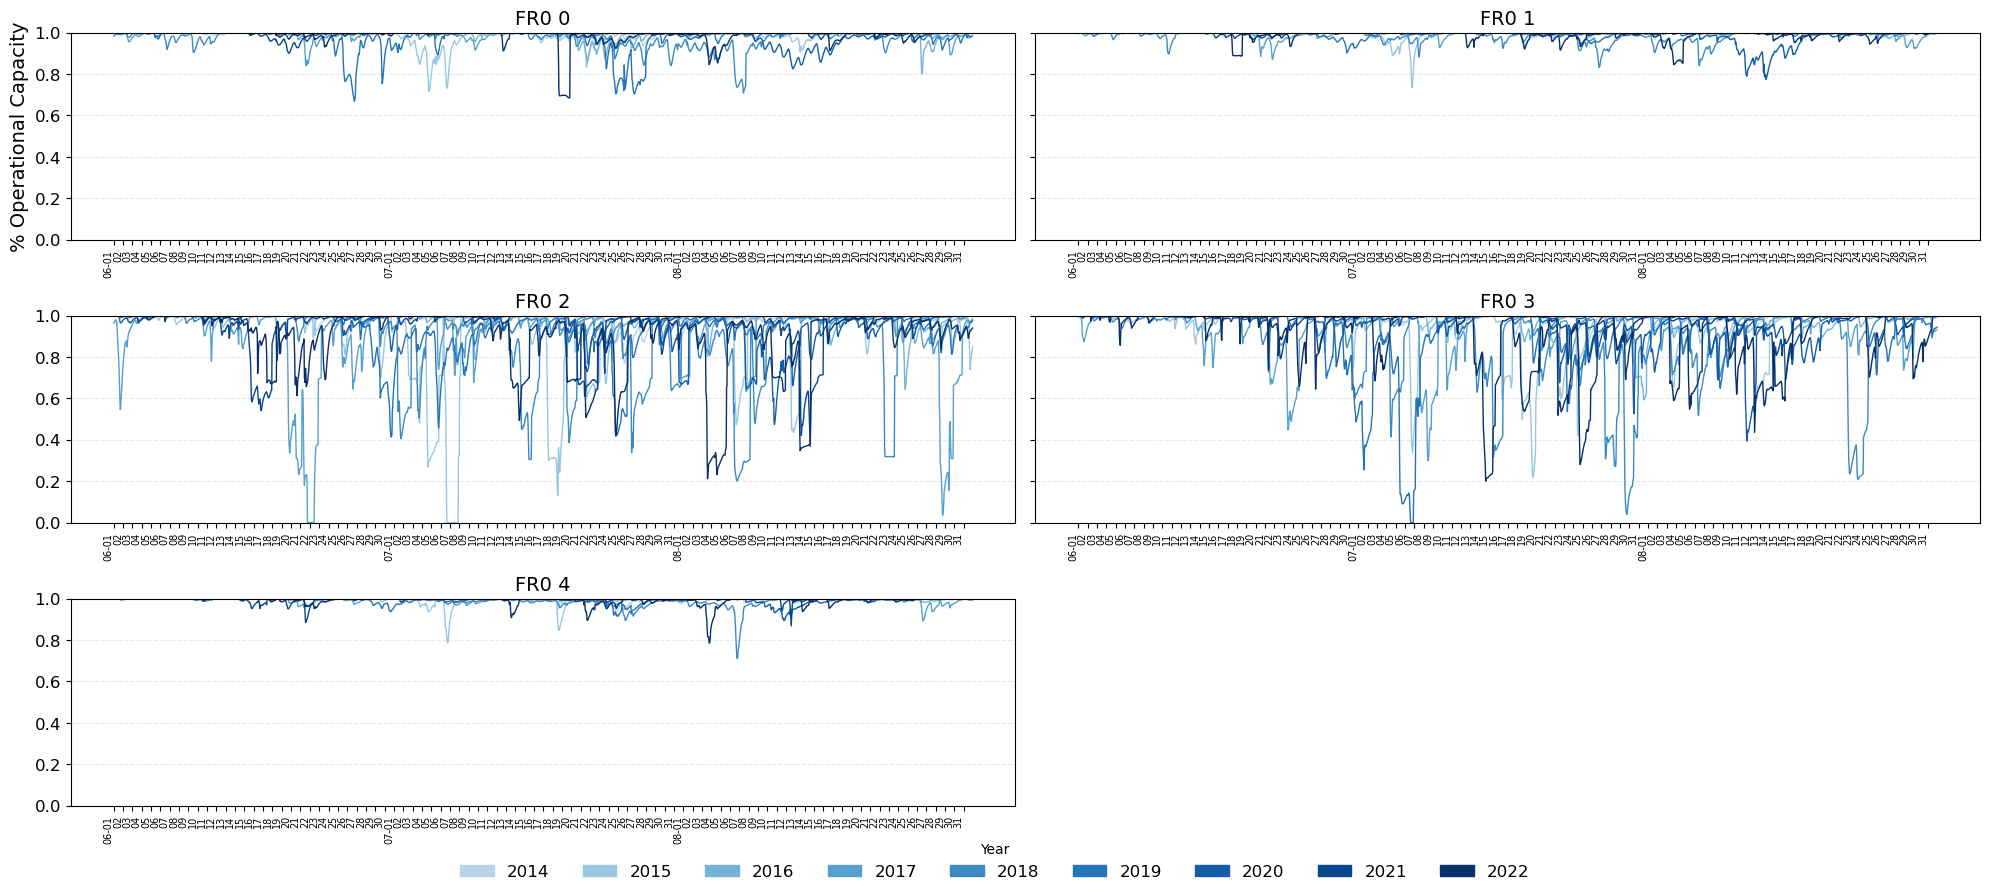

In [13]:
fig, axes = plot_all_buses_multiyear(scenarios_dis)
plt.show()


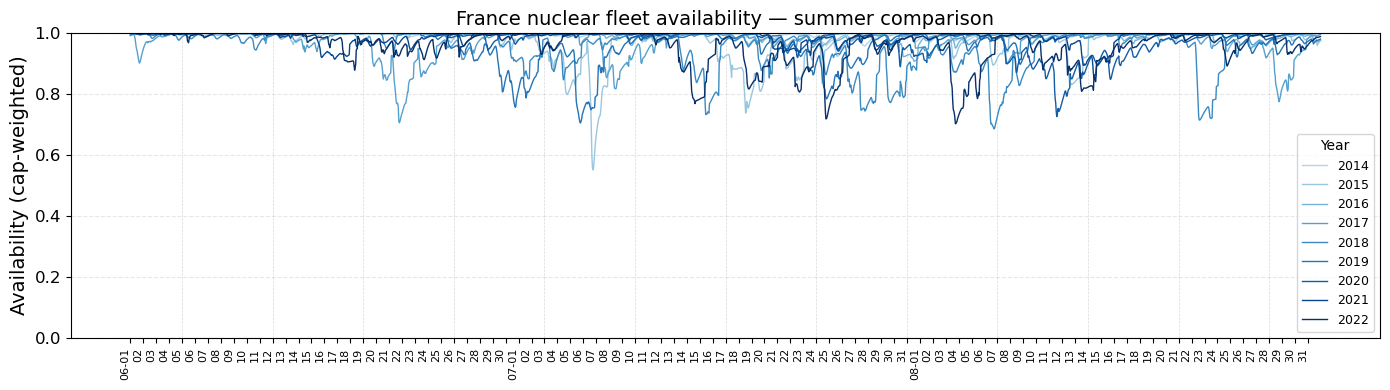

In [62]:
def _fleet_availability(s: dict) -> pd.Series:
    pp = s["powerplants_df"]
    damage_df = s["damage_df"]
    plants = pp[pp["Name"].isin(damage_df.columns)].set_index("Name")
    w = plants["Capacity"]
    return (1 - damage_df[w.index]).mul(w, axis=1).sum(axis=1) / w.sum()


fig, ax = plt.subplots(figsize=(14, 4))
cmap = plt.cm.Blues

for i, (year, s) in enumerate(sorted(scenarios_dis.items())):
    color = cmap(0.3 + 0.7 * i / (len(scenarios_dis) - 1))
    avail = _fleet_availability(s)
    avail = avail.loc[f"{year}-06-01":f"{year}-08-31"]
    x = avail.index.map(lambda t: t.replace(year=2000))
    ax.plot(x, avail.values, label=str(year), linewidth=1.0, color=color)

tickvals, ticktext = _compute_day_ticks(x)
ax.set_xticks(tickvals)
ax.set_xticklabels(ticktext, rotation=90, ha="right", fontsize=8)

# Weekly gridlines based on the reference year index
days_until_monday = (7 - x[0].weekday()) % 7
first_monday = x[0].normalize() + pd.Timedelta(days=days_until_monday)
for d in pd.date_range(first_monday, x[-1], freq="7D"):
    ax.axvline(d, color="grey", alpha=0.3, linestyle="--", linewidth=0.5, zorder=0)

ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.grid(True, which="major", axis="y", alpha=0.3, linestyle="--")
ax.set_ylabel("Availability (cap-weighted)")
ax.set_title("France nuclear fleet availability — summer comparison")
ax.legend(title="Year", loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()


# ENTSOE Metrics

In [8]:
def _aggregate(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    if freq == "h":
        return df
    if freq == "total":
        return pd.DataFrame([df.sum()], index=pd.Index([df.index[0]]))
    return df.resample(freq).sum()

def compute_eoh_nuclear(
    damage_df: pd.DataFrame,
    powerplants_df: pd.DataFrame,
    date_range: tuple | None = None,
    freq: str = "MS",
    granularity: str = "fleet",
) -> pd.DataFrame:
    """
    Equivalent outage hours for nuclear.

    EOH = capacity-weighted sum of hourly damage fractions per period.

    Parameters
    ----------
    damage_df      : plant-level damage fractions (time × plant), values in [0, 1]
    powerplants_df : must have columns Name, bus, Capacity
    date_range     : optional (start, end) ISO strings
    freq           : "h" | "W" | "MS" | "total"
    granularity    : "plant" | "bus" | "fleet"
    """
    pp = powerplants_df[powerplants_df["Name"].isin(damage_df.columns)].copy()
    capacities = pp.set_index("Name")["Capacity"]
    dmg = damage_df[pp["Name"].values].copy()
    if date_range is not None:
        dmg = dmg.loc[date_range[0]:date_range[1]]

    if granularity == "plant":
        return _aggregate(dmg, freq)

    if granularity == "bus":
        bus_map = pp.set_index("Name")["bus"]
        bus_dfs = {}
        for bus, group in pp.groupby("bus"):
            caps = group.set_index("Name")["Capacity"]
            bus_dfs[bus] = dmg[caps.index].mul(caps, axis=1).sum(axis=1) / caps.sum()
        return _aggregate(pd.DataFrame(bus_dfs), freq)

    # fleet
    fleet = dmg.mul(capacities, axis=1).sum(axis=1) / capacities.sum()
    return _aggregate(fleet.rename("fleet").to_frame(), freq)


def compute_potential_energy_loss_nuclear(
    damage_df: pd.DataFrame,
    powerplants_df: pd.DataFrame,
    cf_fixed: float = cf_fixed_factor,
    date_range: tuple | None = None,
    freq: str = "MS",
    granularity: str = "fleet",
) -> pd.DataFrame:
    """
    Potential energy loss (MWh) for nuclear.

    PEL = damage_fraction × cf_fixed × p_nom, aggregated per period.
    cf_fixed is the nuclear equivalent of p_max_pu in the wind formulation.

    Parameters
    ----------
    damage_df      : plant-level damage fractions (time × plant), values in [0, 1]
    powerplants_df : must have columns Name, bus, Capacity
    cf_fixed       : baseline capacity factor (analogous to p_max_pu)
    date_range     : optional (start, end) ISO strings
    freq           : "h" | "W" | "MS" | "total"
    granularity    : "plant" | "bus" | "fleet"
    """
    pp = powerplants_df[powerplants_df["Name"].isin(damage_df.columns)].copy()
    capacities = pp.set_index("Name")["Capacity"]
    dmg = damage_df[pp["Name"].values].copy()
    if date_range is not None:
        dmg = dmg.loc[date_range[0]:date_range[1]]

    pel_plant = dmg.mul(capacities * cf_fixed, axis=1)

    if granularity == "plant":
        return _aggregate(pel_plant, freq)

    if granularity == "bus":
        bus_map = pp.set_index("Name")["bus"]
        pel_bus = pel_plant.T.groupby(bus_map).sum().T
        return _aggregate(pel_bus, freq)

    # fleet
    return _aggregate(pel_plant.sum(axis=1).rename("fleet").to_frame(), freq)


In [9]:
eoh_by_year = {
    year: compute_eoh_nuclear(
        s["damage_df"], s["powerplants_df"],
        freq="MS", granularity="fleet",
    )
    for year, s in scenarios_dis.items()
}

# Stack into a single DataFrame with year as a column
eoh_all = pd.concat(eoh_by_year, axis=0)
eoh_all.index.names = ["year", "period"]


In [10]:
eoh_all

fleet
year period              
2014 2014-06-01  0.784301
     2014-07-01  6.548295
     2014-08-01  2.908800
     2014-09-01  0.632878
     2014-10-01  0.000000
...                   ...
2022 2023-01-01  0.000000
     2023-02-01  0.000000
     2023-03-01  0.000000
     2023-04-01  0.000000
     2023-05-01  0.103505

[108 rows x 1 columns]

In [11]:
pel_total = pd.concat(
    {year: compute_potential_energy_loss_nuclear(
        s["damage_df"], s["powerplants_df"],
        freq="total", granularity="fleet", cf_fixed = 0.616
    )
     for year, s in scenarios_dis.items()}
).droplevel(1)


In [12]:
pel_total

,fleet
2014,4.233874e+05
2015,2.450135e+06
2016,9.994046e+05
2017,2.483240e+06
2018,4.157359e+06
2019,2.755148e+06
2020,1.943491e+06
2021,1.400564e+06
2022,3.951840e+06


In [13]:
pel_total

,fleet
2014,4.233874e+05
2015,2.450135e+06
2016,9.994046e+05
2017,2.483240e+06
2018,4.157359e+06
2019,2.755148e+06
2020,1.943491e+06
2021,1.400564e+06
2022,3.951840e+06


In [14]:
from matplotlib.lines import Line2D

In [19]:
def plot_fleet_metrics_multiyear(
    fleets: dict,
    title: str | None = None,
    multiplier: float = 1e-6,
    unit: str = "TWh",
) -> tuple:
    cmap = plt.cm.Blues
    years = sorted(fleets)
    months = range(1, 13)
    month_labels = [pd.Timestamp(f"2000-{m:02d}-01").strftime("%b") for m in months]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    reindexed = {}
    for i, year in enumerate(years):
        color = cmap(0.3 + 0.7 * i / (len(years) - 1))
        df = fleets[year].set_index(fleets[year].index.month).reindex(months)
        reindexed[year] = df

        ax1.plot(months, df["energy_loss_mwh"] * multiplier, marker="o", markersize=3,
                 linewidth=1.2, color=color, label=str(year))
        ax2.plot(months, df["eoh"], marker="o", markersize=3,
                 linewidth=1.2, color=color, label=str(year))

    mean_el  = pd.DataFrame({y: d["energy_loss_mwh"] for y, d in reindexed.items()}).mean(axis=1)
    mean_eoh = pd.DataFrame({y: d["eoh"]             for y, d in reindexed.items()}).mean(axis=1)

    ax1.plot(months, mean_el * multiplier,  linewidth=2.5, color="black", linestyle="--", label="Mean")
    ax2.plot(months, mean_eoh, linewidth=2.5, color="black", linestyle="--", label="Mean")

    ax1.set_ylabel(f"Potential Energy Loss ({unit})")
    ax1.yaxis.grid(True, alpha=0.3, linestyle="--")
    ax1.set_axisbelow(True)

    ax2.set_ylabel("Equivalent outage hours")
    ax2.set_xticks(list(months))
    ax2.set_xticklabels(month_labels)
    ax2.yaxis.grid(True, alpha=0.3, linestyle="--")
    ax2.set_axisbelow(True)

    handles = [
        mpatches.Patch(color=cmap(0.3 + 0.7 * i / (len(years) - 1)), label=str(y))
        for i, y in enumerate(years)
    ]
    handles.append(mpl.lines.Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Mean"))

    fig.legend(handles=handles, title="Year", loc="upper right",
               bbox_to_anchor=(1.0, 0.98), frameon=False)

    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    return fig, (ax1, ax2)


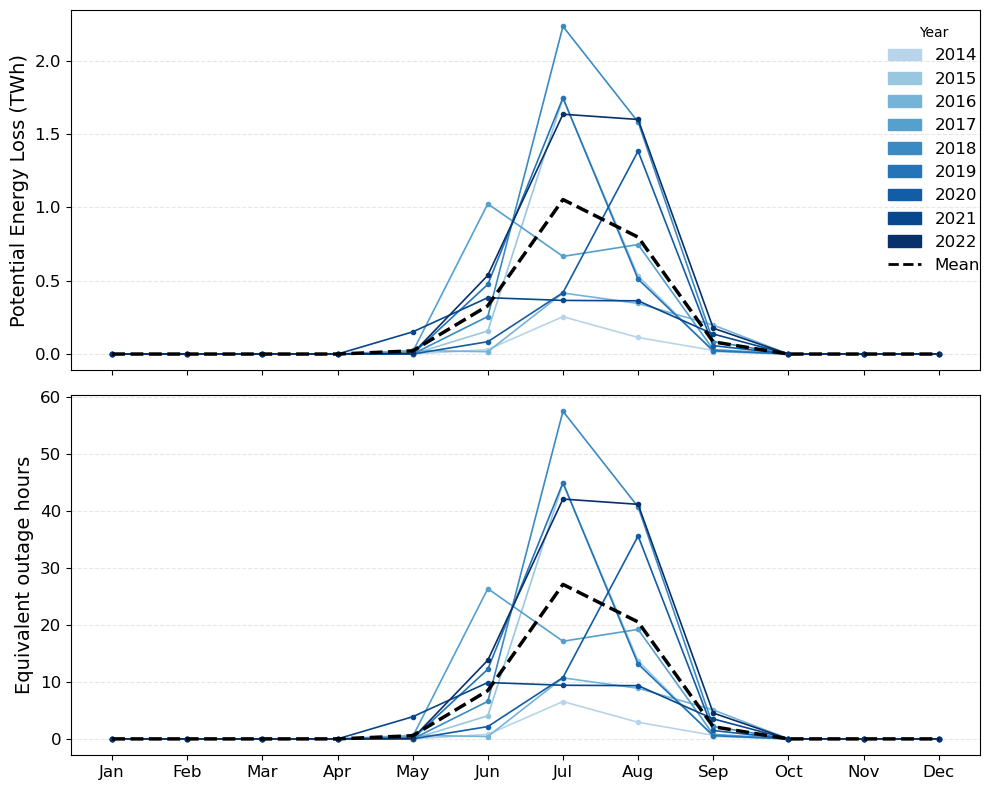

In [20]:
fleets = {
    year: pd.concat([
        compute_potential_energy_loss_nuclear(s["damage_df"], s["powerplants_df"], freq="MS", granularity="fleet").rename(columns={"fleet": "energy_loss_mwh"}),
        compute_eoh_nuclear(s["damage_df"], s["powerplants_df"], freq="MS", granularity="fleet").rename(columns={"fleet": "eoh"}),
    ], axis=1)
    for year, s in scenarios_dis.items()
    
}

fig, axes = plot_fleet_metrics_multiyear(
    # multiplier=1e-3, unit="GWh",
    fleets, 
    title=""
    )
plt.show()


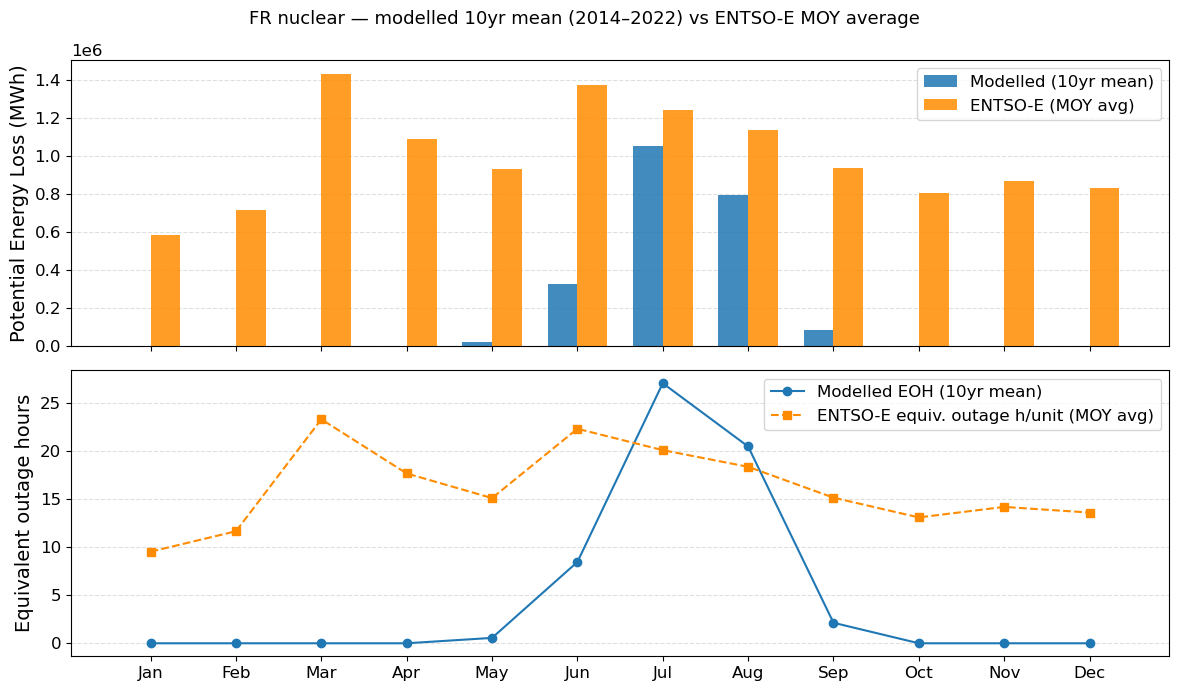

In [22]:
# ── ENTSO-E FR nuclear (month-of-year averages, multi-year) ──────────────────
_kpis_path = (
    Path("../../../pypsa-damage")
    / "Jahnke_Ardone"
    / "dataset/kpis_plant_MOY.csv"
)
_kpis = pd.read_csv(_kpis_path, sep=";")

df_entsoe = _kpis[
    (_kpis["country"] == "FR") & (_kpis["plant_type"] == "Nuclear")
].copy()
df_entsoe["month"] = df_entsoe["period_key"].astype(int)
df_entsoe = df_entsoe.sort_values("month").reset_index(drop=True)
df_entsoe["equiv_outage_h_per_unit"] = df_entsoe["wEUOR"] * (df_entsoe["D_h"] / df_entsoe["n_units"])
df_entsoe["energy_loss_mwh_total"]   = df_entsoe["equiv_outage_h_per_unit"] * df_entsoe["cap_total_MW"]

# ── Cross-year mean by month ──────────────────────────────────────────────────
months = range(1, 13)
month_labels = [pd.Timestamp(f"2000-{m:02d}-01").strftime("%b") for m in months]

reindexed = {
    year: df.set_index(df.index.month).reindex(months)
    for year, df in fleets.items()
}
mean_el  = pd.DataFrame({y: d["energy_loss_mwh"] for y, d in reindexed.items()}).mean(axis=1)
mean_eoh = pd.DataFrame({y: d["eoh"]             for y, d in reindexed.items()}).mean(axis=1)

entsoe_m = df_entsoe.set_index("month").reindex(list(months))

# ── Plot ─────────────────────────────────────────────────────────────────────
x = np.arange(12)
w = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.bar(x - w/2, mean_el.values,                    width=w, color="#1f77b4",    alpha=0.85, label="Modelled (10yr mean)")
ax1.bar(x + w/2, entsoe_m["energy_loss_mwh_total"], width=w, color="darkorange", alpha=0.85, label="ENTSO-E (MOY avg)")
ax1.set_ylabel("Potential Energy Loss (MWh)")
ax1.legend(); ax1.yaxis.grid(True, linestyle="--", alpha=0.4); ax1.set_axisbelow(True)

ax2.plot(x, mean_eoh.values,                     marker="o", color="#1f77b4",    label="Modelled EOH (10yr mean)")
ax2.plot(x, entsoe_m["equiv_outage_h_per_unit"], marker="s", color="darkorange", label="ENTSO-E equiv. outage h/unit (MOY avg)", linestyle="--")
ax2.set_ylabel("Equivalent outage hours")
ax2.set_xticks(x); ax2.set_xticklabels(month_labels)
ax2.legend(); ax2.yaxis.grid(True, linestyle="--", alpha=0.4); ax2.set_axisbelow(True)

fig.suptitle("FR nuclear — modelled 10yr mean (2014–2022) vs ENTSO-E MOY average", fontsize=13)
fig.tight_layout()
plt.show()


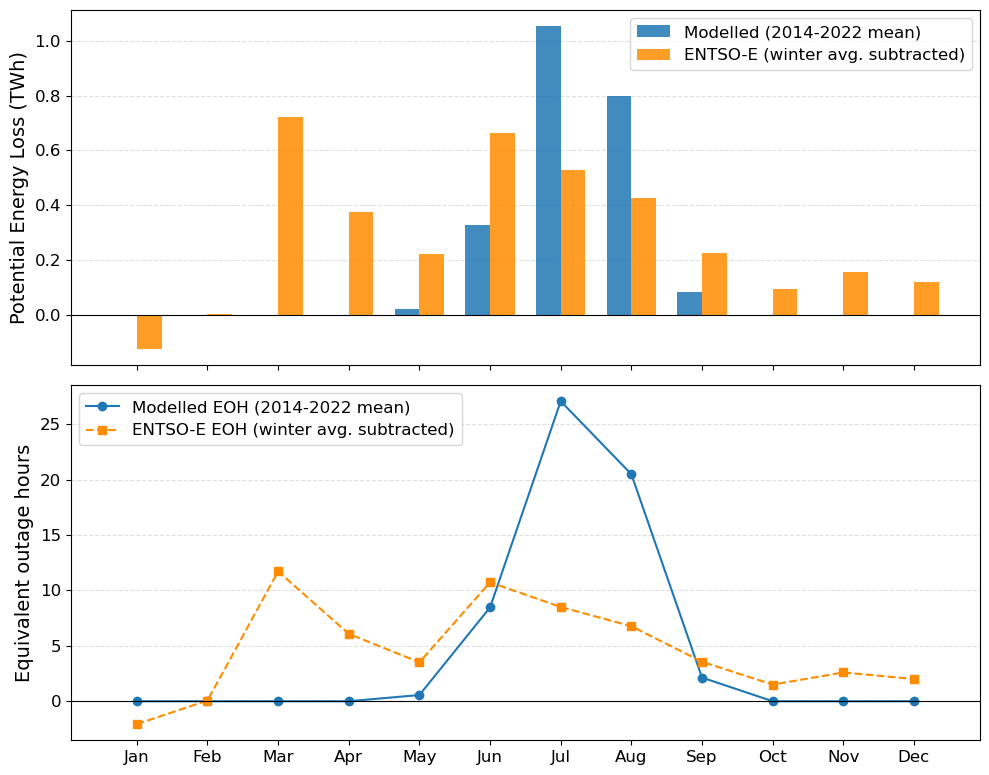

In [28]:
# ── Winter baseline anomaly — ENTSO-E only ───────────────────────────────────
winter = [12, 1, 2]

entsoe_el_anom  = entsoe_m["energy_loss_mwh_total"]  - entsoe_m.loc[winter, "energy_loss_mwh_total"].mean()
entsoe_eoh_anom = entsoe_m["equiv_outage_h_per_unit"] - entsoe_m.loc[winter, "equiv_outage_h_per_unit"].mean()

# ── Plot ──────────────────────────────────────────────────────────────────────
multiplier = 1e-6
unit = "TWh"

x = np.arange(12)
w = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.bar(x - w/2, mean_el.values * multiplier,        width=w, color="#1f77b4",    alpha=0.85, label="Modelled (2014-2022 mean)")
ax1.bar(x + w/2, entsoe_el_anom.values * multiplier, width=w, color="darkorange", alpha=0.85, label="ENTSO-E (winter avg. subtracted)")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel(f"Potential Energy Loss ({unit})")
ax1.legend(); ax1.yaxis.grid(True, linestyle="--", alpha=0.4); ax1.set_axisbelow(True)

ax2.plot(x, mean_eoh.values,        marker="o", color="#1f77b4",    label="Modelled EOH (2014-2022 mean)")
ax2.plot(x, entsoe_eoh_anom.values, marker="s", color="darkorange", label="ENTSO-E EOH (winter avg. subtracted)", linestyle="--")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Equivalent outage hours")
ax2.set_xticks(x); ax2.set_xticklabels(month_labels)
ax2.legend(); ax2.yaxis.grid(True, linestyle="--", alpha=0.4); ax2.set_axisbelow(True)

fig.suptitle("", fontsize=13)
fig.tight_layout()
plt.show()


# Network Collection

In [77]:
from pypsa import NetworkCollection
from plot_stats import compute_stats_diff, format_stats_df, iplot_stats_bar, plot_stats_bar

def _network_paths(year: int) -> dict:
    return {
        "base_cap": _results / f"weather_year_{year}_nuc_base" / "networks" / "base_s_5_elec_.nc",
        "base_dis": _results / f"weather_year_{year}_nuc_base" / "networks" / "base_s_5_elec__op.nc",
        "cap":      _results / f"weather_year_{year}_nuc_cap"  / "networks" / "base_s_5_elec_.nc",
        "dis":      _results / f"weather_year_{year}_nuc_dis"  / "networks" / "base_s_5_elec__damaged-dispatch.nc",
    }


def compute_multiyear_stats(years: list) -> pd.DataFrame:
    grouper = ["bus", "carrier", "bus_carrier"]
    diffs = []
    for year in years:
        networks = {label: pypsa.Network(path) for label, path in _network_paths(year).items()}
        nc_year  = NetworkCollection(list(networks.values()), index=list(networks.keys()))
        stats    = nc_year.statistics(groupby=grouper, nice_names=False)
        stats["Expanded Capacity"] = stats["Optimal Capacity"] - stats["Installed Capacity"]
        diff = compute_stats_diff(stats, base="base_cap")
        diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
        diff["year"] = year
        diffs.append(diff)
    return pd.concat(diffs, ignore_index=True)


# Usage — specify which years you want:
diff_multi = compute_multiyear_stats([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current:

In [79]:
from plot_combo import (
    plot_combination_profile,
    format_ts_df, format_ts_diff_df,
    build_eb_diff_by_bus, build_storage_dict,
)

In [80]:
SUP_CARRIERS = [
        'biomass', 'nuclear', 'offwind-ac', 'offwind-dc',
       'onwind', 'solar', 'solar-hsat', 'load_shedding', 'ror', 'biomass']

CHARGE_CARRIERS = ['H2 electrolysis','H2 fuel cell','battery', 'PSH', 'hydro']
STOR_CARRIERS = ['H2 fuel cell']

GRID_CARRIERS = [
        'AC', 'DC', 'H2'
        ]
_any_network = pypsa.Network(next(iter(DIS_NETWORK_PATHS.values())))
color_map = _any_network.carriers.color.to_dict()

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [81]:
color_map

{'AC': '#70af1d',
 'DC': '#8a1caf',
 'CCGT': '#a85522',
 'oil': '#c9c9c9',
 'biomass': '#baa741',
 'ror': '#3dbfb0',
 'coal': '#545454',
 'nuclear': '#ff8c00',
 'lignite': '#826837',
 'onwind': '#235ebc',
 'solar': '#f9d002',
 'offwind-ac': '#6895dd',
 'offwind-dc': '#74c6f2',
 'hydro': '#298c81',
 'solar-hsat': '#fdb915',
 'PHS': '#51dbcc',
 'battery': '#ace37f',
 'H2': '#bf13a0',
 'H2 fuel cell': '#c251ae',
 'H2 electrolysis': '#ff29d9',
 '': '',
 'load_shedding': ''}

In [86]:
# noisy cost
n = networks["base"]  # or any loaded network

vom = pd.concat([
    n.generators[["carrier", "marginal_cost"]].rename(columns={"marginal_cost": "vom"}),
    n.links[["carrier", "marginal_cost"]].rename(columns={"marginal_cost": "vom"}),
])

vom[vom["vom"] > 0].sort_values("vom", ascending=False)


,carrier,vom
name,,
FR0 4 oil,oil,157.533328
FR0 1 oil,oil,157.533236
FR0 4 CCGT,CCGT,52.663327
FR0 3 CCGT,CCGT,46.372210
FR0 0 CCGT,CCGT,45.678428
FR0 2 CCGT,CCGT,45.188918
FR0 1 CCGT,CCGT,45.090735
FR0 3 coal,coal,30.109289
FR0 4 coal,coal,30.108486


(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'base_cap'}, xlabel='Bus', ylabel='optimal capacity (GW)'>])

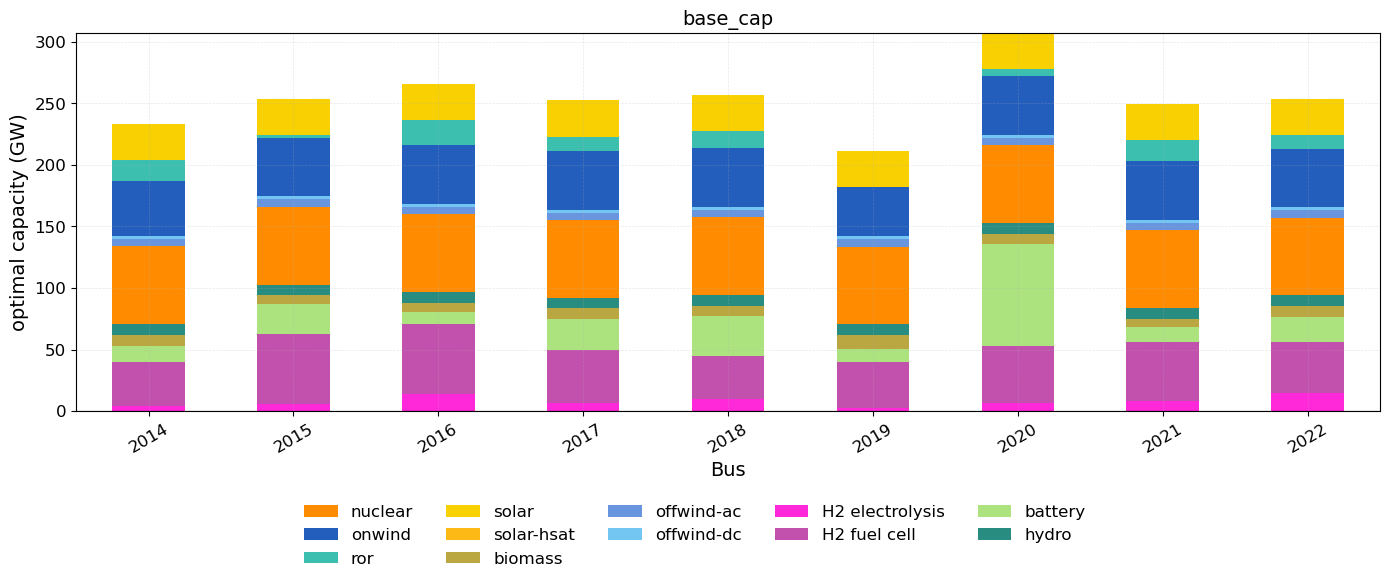

In [83]:
diff_plot = diff_multi[diff_multi["network"] == "base_cap"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)


plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="optimal capacity",
    networks=["base_cap"],
    multiplier=1e-3,
    title="optimal capacity (GW)",
    color_map=color_map
)


(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'base_dis'}, xlabel='Bus', ylabel='optimal capacity (GW)'>])

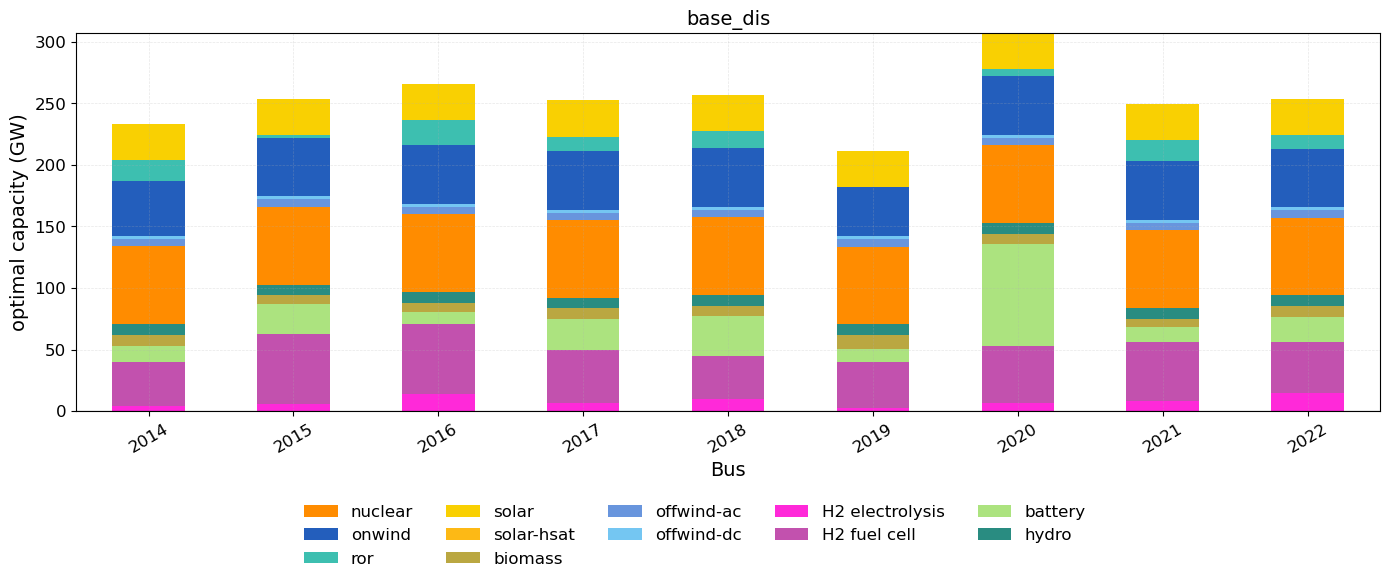

In [84]:
diff_plot = diff_multi[diff_multi["network"] == "base_dis"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)


plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="optimal capacity",
    networks=["base_dis"],
    multiplier=1e-3,
    title="optimal capacity (GW)",
    color_map=color_map
)


(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'base_cap'}, xlabel='Bus', ylabel='expanded capacity (GW)'>])

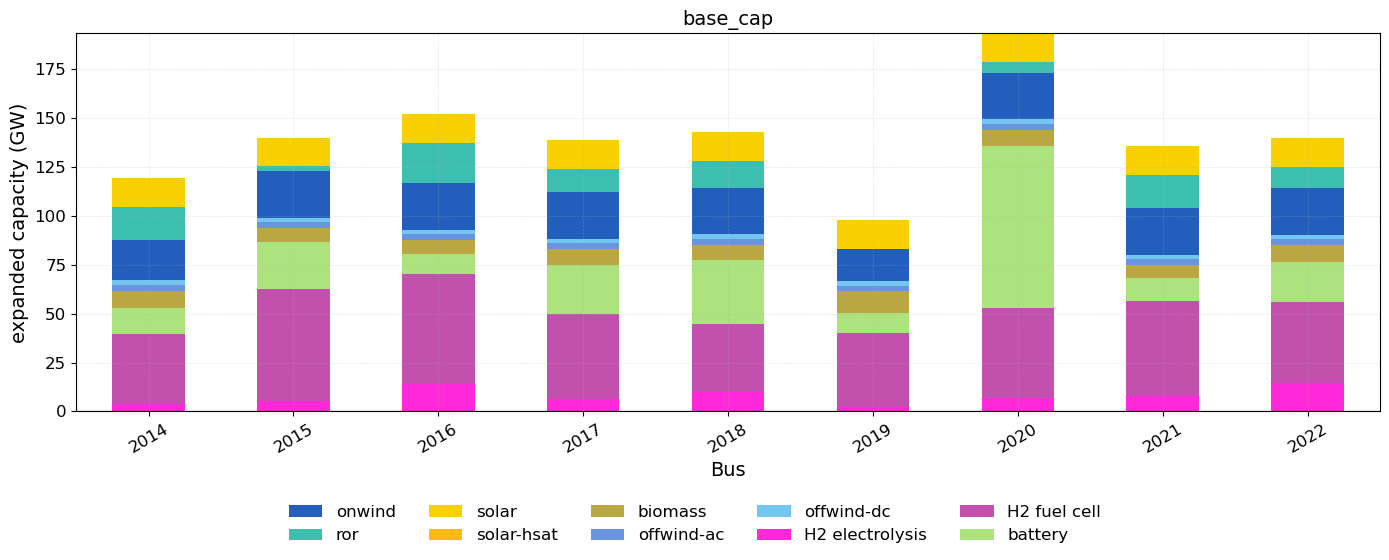

In [85]:
diff_plot = diff_multi[diff_multi["network"] == "base_cap"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)


plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="expanded capacity",
    networks=["base_cap"],
    multiplier=1e-3,
    title="expanded capacity (GW)",
    color_map=color_map
)


(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'base_cap'}, xlabel='Bus', ylabel='installed capacity (GW)'>])

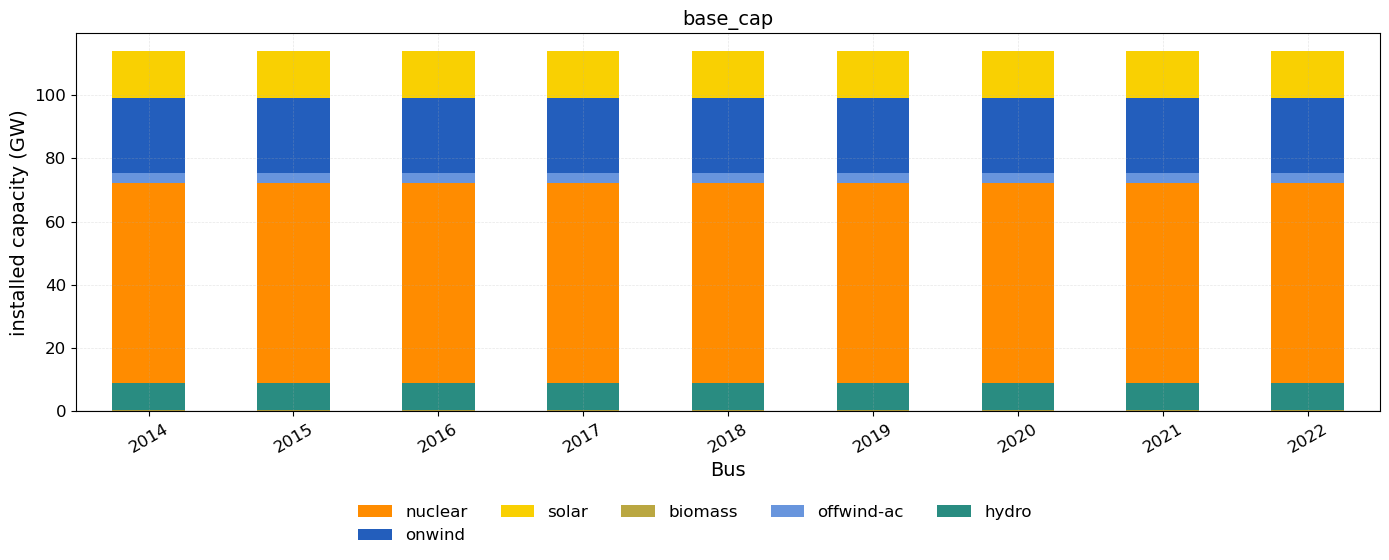

In [86]:
diff_plot = diff_multi[diff_multi["network"] == "base_cap"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)


plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="installed capacity",
    networks=["base_cap"],
    multiplier=1e-3,
    title="installed capacity (GW)",
    color_map=color_map
)


(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Energy balance diff (GWh)'>])

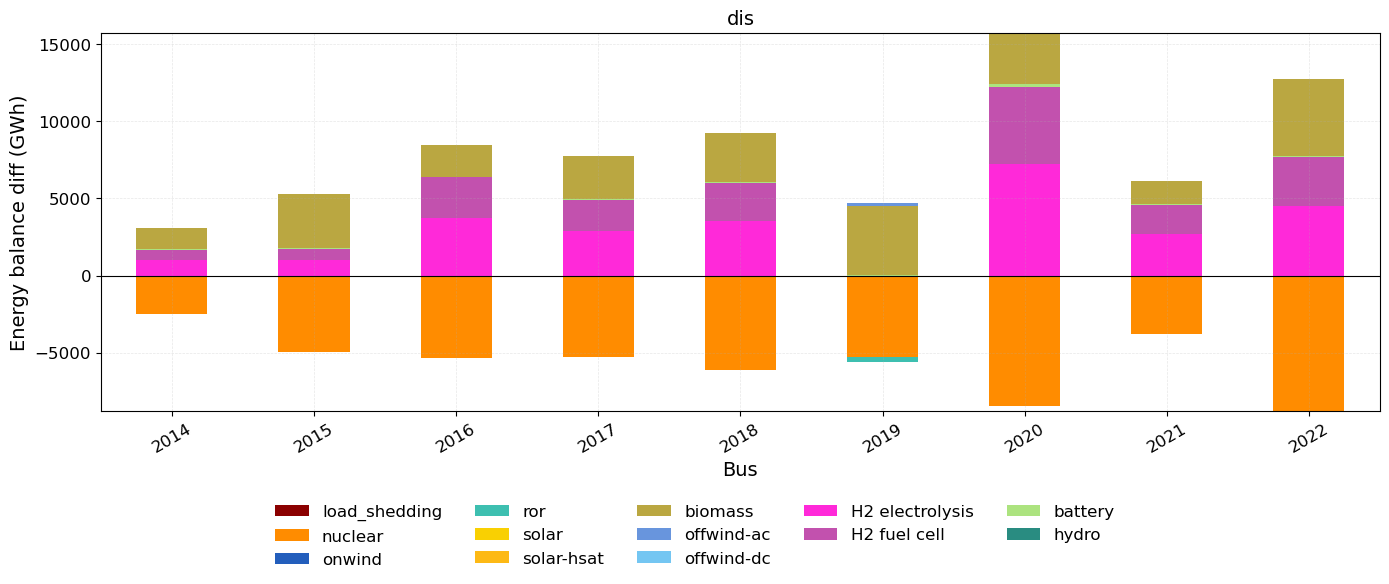

In [87]:
diff_plot = diff_multi[diff_multi["network"] == "dis"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)


plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1e-3,
    title="Energy balance diff (GWh)",
    color_map=color_map
)


(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Energy balance diff (GWh)'>])

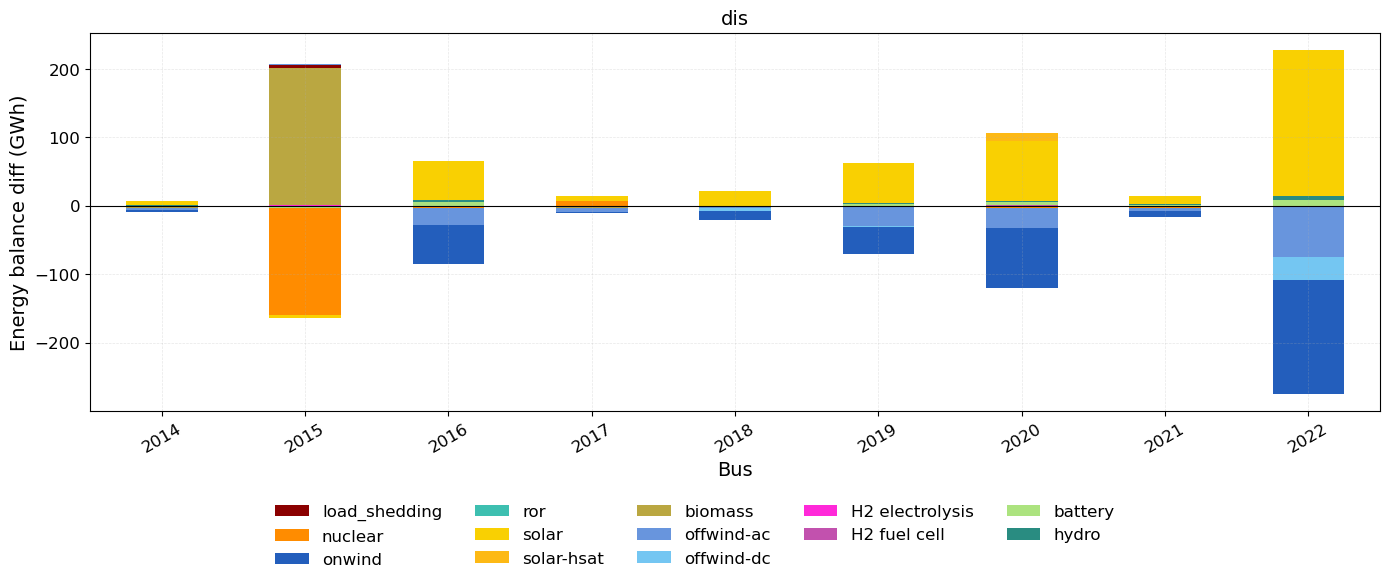

In [ ]:
diff_plot = diff_multi[diff_multi["network"] == "dis"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)


plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1e-3,
    title="Energy balance diff (GWh)",
    color_map=color_map
)


In [88]:
# In 10yr notebook  
diff_10yr_2022 = diff_multi[
    (diff_multi["year"] == 2022) & diff_multi["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
].groupby("tech")["energy_balance_diff"].sum()

print(diff_10yr_2022)

tech
H2 electrolysis    9.242733e+06
H2 fuel cell       6.464368e+06
battery            1.838293e+05
biomass            8.050925e+06
hydro              1.530106e+02
load_shedding      1.334800e-01
nuclear           -2.137640e+07
offwind-ac         3.077135e+02
offwind-dc         1.599515e+02
onwind             4.354213e+02
ror                5.687201e+06
solar              1.091393e+02
solar-hsat         2.583392e+02
Name: energy_balance_diff, dtype: float64


(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Load Shedding (MWh)'>])

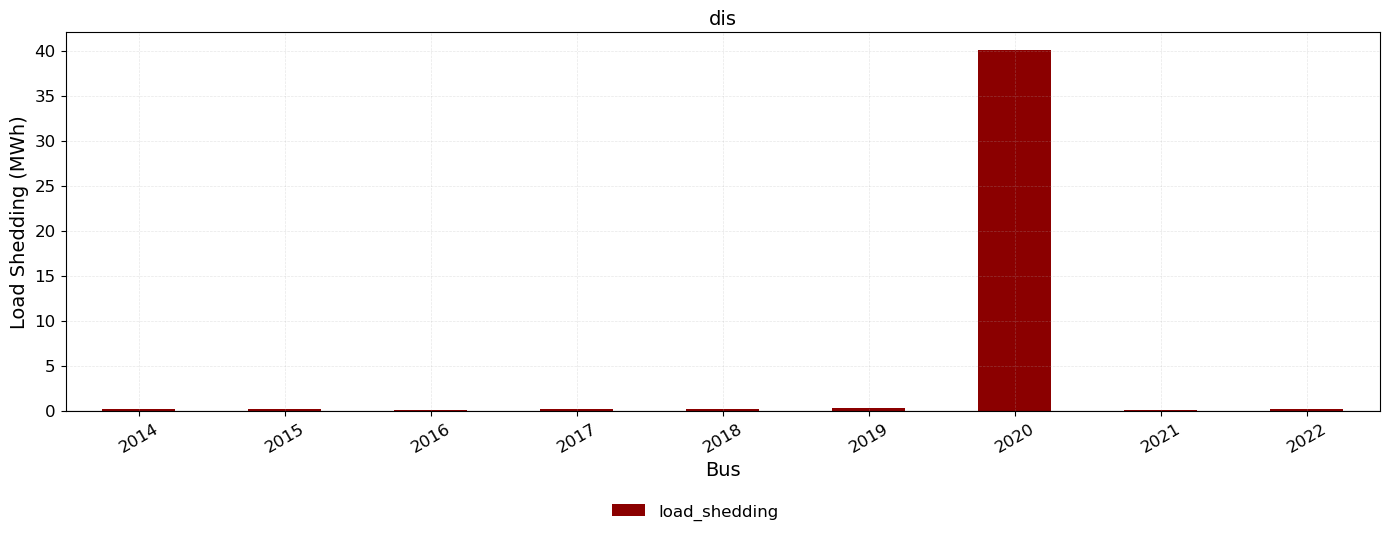

In [89]:
plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(["load_shedding"])],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1,
    title="Load Shedding (MWh)",
    color_map=color_map
)

(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Load Shedding (MWh)'>])

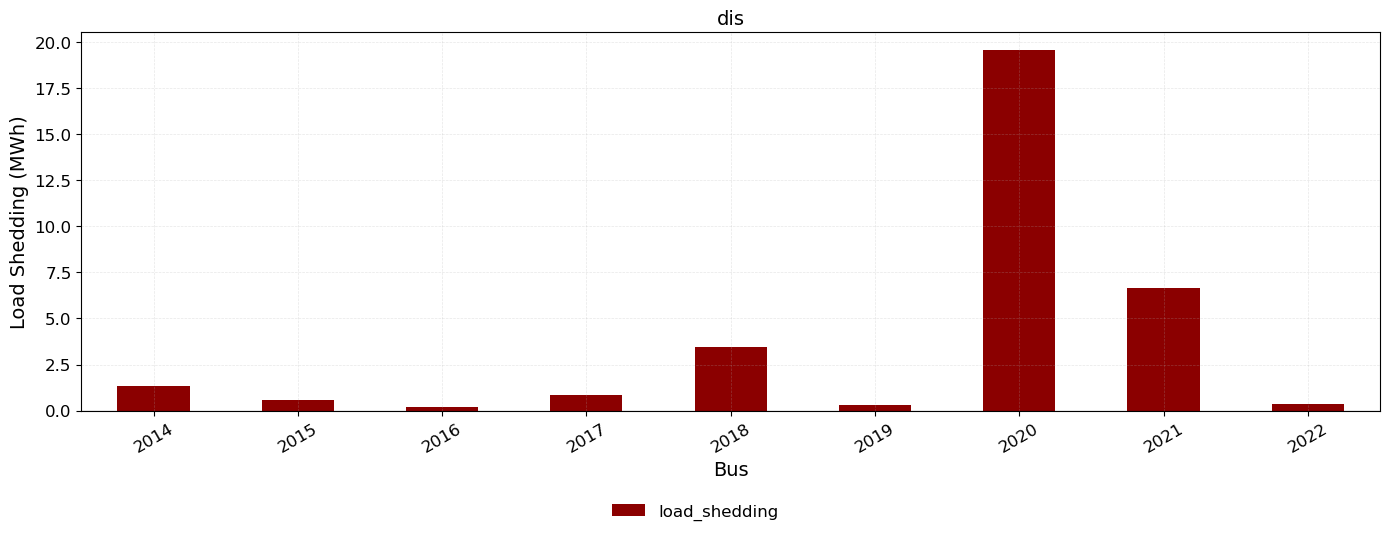

In [ ]:
plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(["load_shedding"])],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1,
    title="Load Shedding (MWh)",
    color_map=color_map
)

(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Nuclear energy balance diff (MWh)'>])

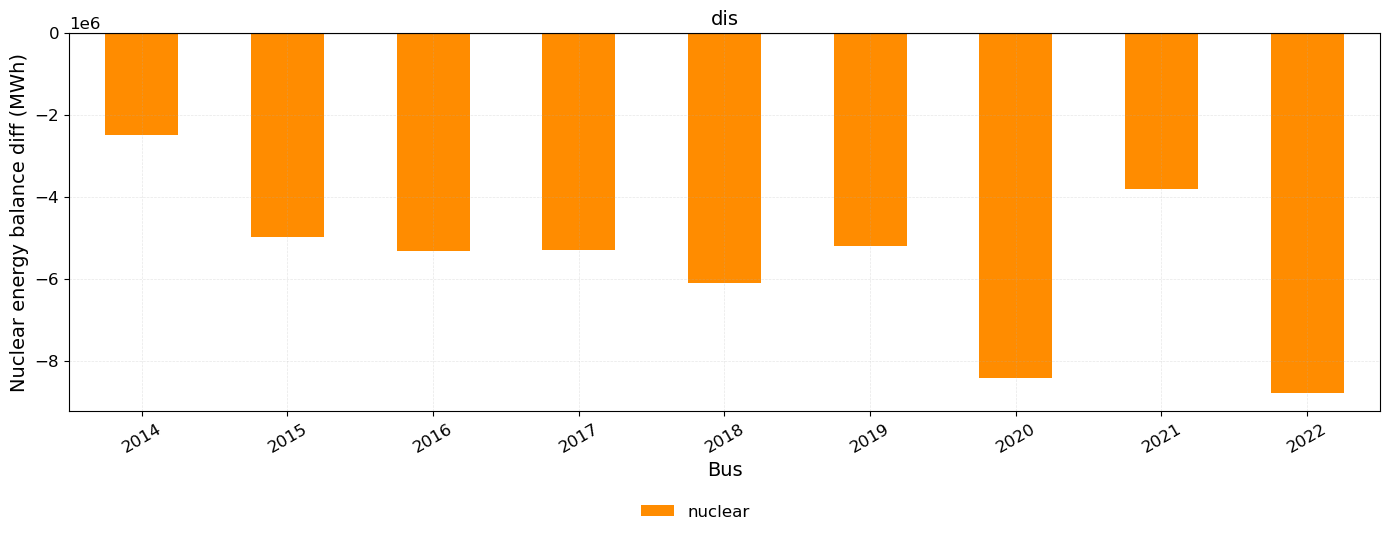

In [90]:
diff_plot = diff_multi[diff_multi["network"] == "dis"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)

plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(["nuclear"])],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1,
    title="Nuclear energy balance diff (MWh)",
    color_map=color_map
)

(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Nuclear energy balance diff (MWh)'>])

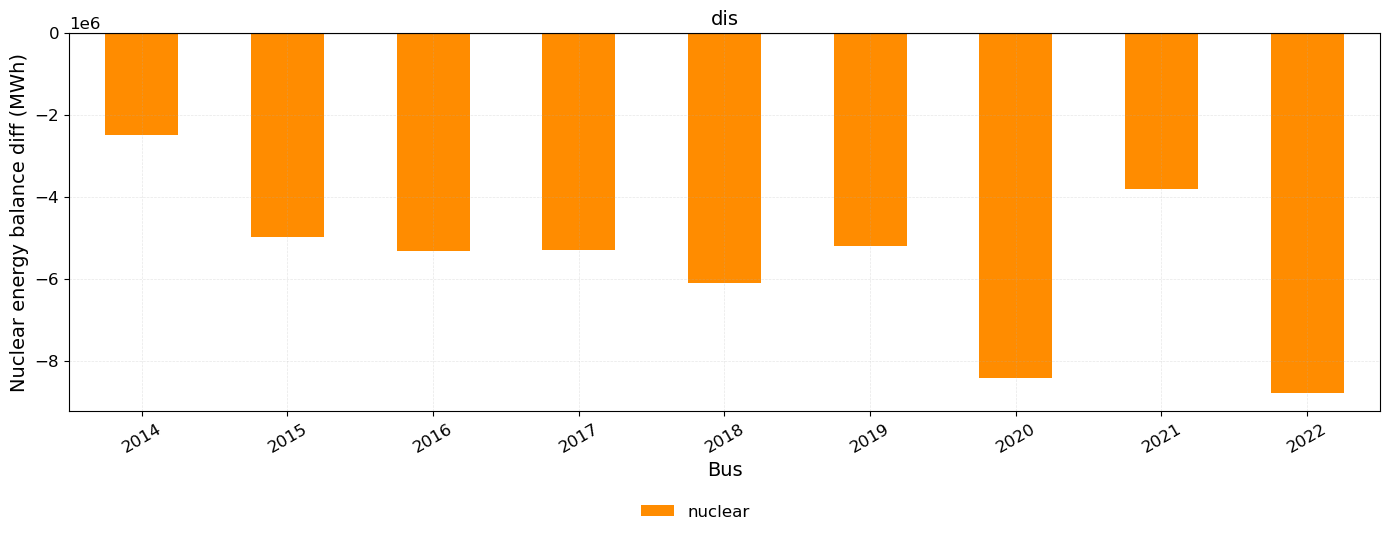

In [91]:
diff_plot = diff_multi[diff_multi["network"] == "dis"].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)

plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(["nuclear"])],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1,
    title="Nuclear energy balance diff (MWh)",
    color_map=color_map
)

(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Nuclear energy balance (MWh)'>])

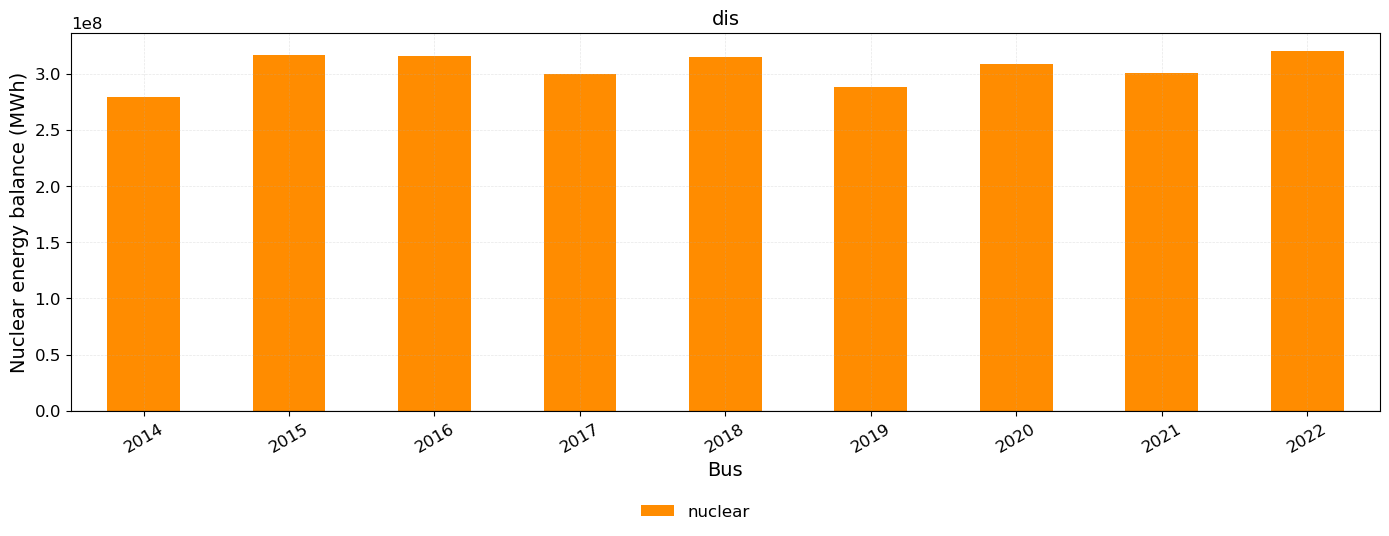

In [92]:
plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(["nuclear"])],
    column="energy balance",
    networks=["dis"],
    multiplier=1,
    title="Nuclear energy balance (MWh)",
    color_map=color_map
)

(<Figure size 1400x500 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Nuclear energy balance (MWh)'>])

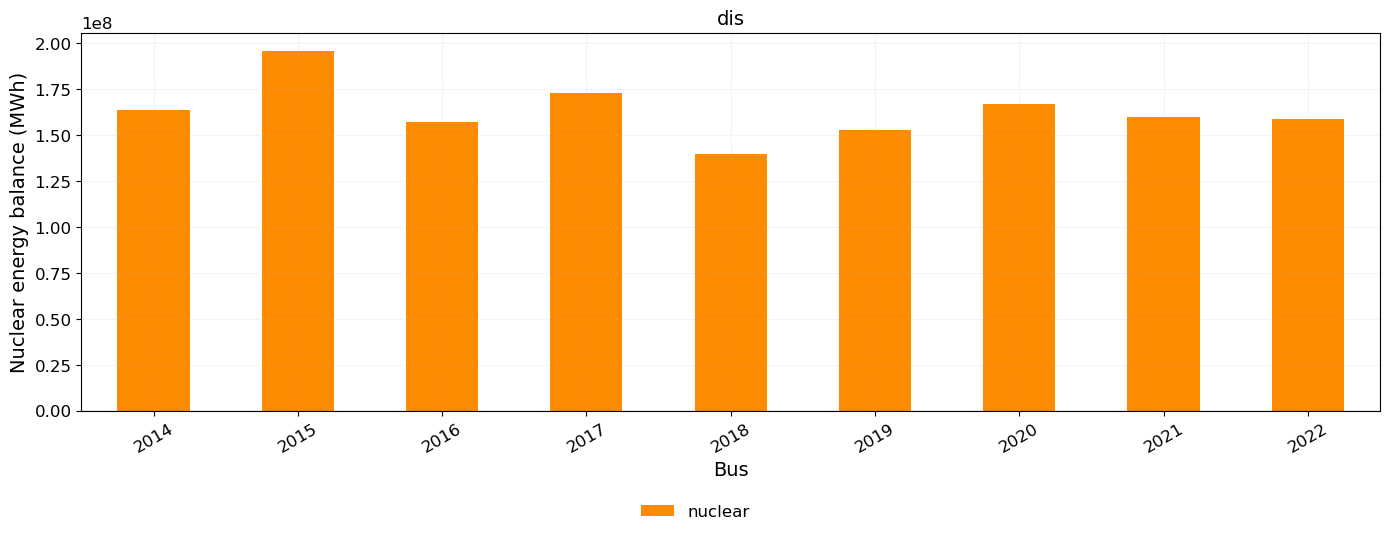

In [ ]:
plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(["nuclear"])],
    column="energy balance",
    networks=["dis"],
    multiplier=1,
    title="Nuclear energy balance (MWh)",
    color_map=color_map
)

In [93]:
def plot_stats_area(
    df,
    *,
    networks,
    bus_carriers,
    date_range=None,
    color_map=None,
    title=None,
    multiplier=1.0,
    show_legend=True,
    aggregate=False,
    facet_col="network",
    facet_row="bus_carrier",
    figsize=(14, 5),
):
    data = df[df["network"].isin(networks)].copy()
    data = data[data["bus_carrier"].isin(bus_carriers)]
    if date_range is not None:
        start, end = pd.Timestamp(date_range[0]), pd.Timestamp(date_range[1])
        data = data[(data["snapshot"] >= start) & (data["snapshot"] <= end)]
    if multiplier != 1.0:
        data["value"] = data["value"] * multiplier

    effective_map = {**(color_map or {}), **_CARRIER_COLOR_OVERRIDES}

    col_vals = networks     if facet_col == "network" else bus_carriers
    row_vals = bus_carriers if facet_row == "bus_carrier" else networks

    if aggregate:
        row_index = [(rv, None) for rv in row_vals]
    else:
        row_index = [
            (rv, bus)
            for rv in row_vals
            for bus in sorted(data[data[facet_row] == rv]["bus"].unique())
        ]

    n_rows, n_cols = len(row_index), len(col_vals)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=False, squeeze=False)

    for row_i, (rv, bus) in enumerate(row_index):
        for col_i, cv in enumerate(col_vals):
            ax = axes[row_i, col_i]
            slice_ = data[(data[facet_col] == cv) & (data[facet_row] == rv)]
            if bus is not None:
                slice_ = slice_[slice_["bus"] == bus]

            pivot = (
                slice_.groupby(["snapshot", "carrier"])["value"]
                .sum()
                .unstack(fill_value=0)
            )

            if pivot.empty:
                ax.set_visible(False)
                continue

            for clipped in [pivot.clip(lower=0), pivot.clip(upper=0)]:
                active = clipped.loc[:, (clipped != 0).any()]
                if active.empty:
                    continue
                colors = [effective_map.get(c) or "#aaaaaa" for c in active.columns]
                ax.stackplot(active.index, active.T.values, colors=colors, alpha=0.85)

            ax.axhline(0, color="black", linewidth=0.8)
            ax.grid(True, axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
            ax.tick_params(axis="x", rotation=30)

            if row_i == 0:
                ax.set_title(cv)
            if col_i == 0:
                row_label = rv if bus is None else f"{rv} | {bus}"
                ax.set_ylabel(f"{row_label}\n{title or 'value'}")

    if show_legend:
        all_carriers = data["carrier"].unique()
        handles = [mpatches.Patch(facecolor=effective_map.get(c) or "#aaaaaa", label=c) for c in all_carriers]
        ncols = min(len(handles), 5)
        fig.tight_layout()
        ax_bottom = min(ax.get_position().y0 for ax in axes[-1])
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, ax_bottom - 0.03),
                   bbox_transform=fig.transFigure, ncol=ncols, frameon=False)
    else:
        fig.tight_layout()

    return fig, axes

_CARRIER_COLOR_OVERRIDES = {"load_shedding": "darkred"}


In [94]:
# ── Select year ───────────────────────────────────────────────────────────────
YEAR = 2022

networks = {label: pypsa.Network(path) for label, path in _network_paths(YEAR).items()}
nc = NetworkCollection(list(networks.values()), index=list(networks.keys()))

base = "base_dis"

ts_eb = format_ts_df(nc, stat="energy_balance")

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


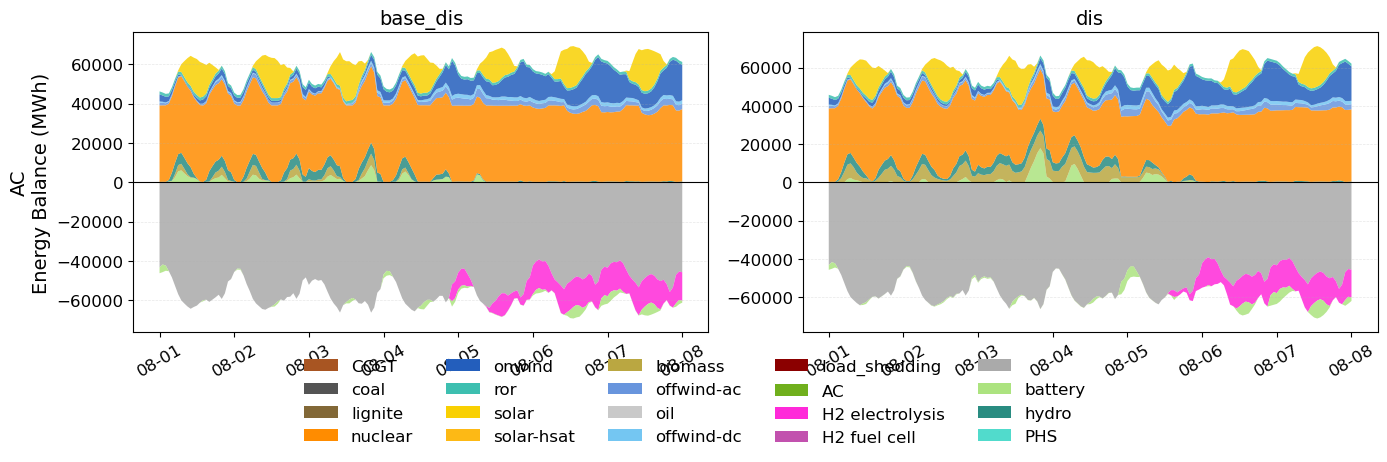

In [95]:
fig, axes = plot_stats_area(
    ts_eb,
    networks=["base_dis", "dis"],
    bus_carriers=["AC"],
    date_range=(f"{YEAR}-08-01", f"{YEAR}-08-08"),
    color_map=networks["base_dis"].carriers.color.to_dict(),
    title="Energy Balance (MWh)",
    aggregate=True,
    facet_col="network",
    facet_row="bus_carrier",
    figsize=(14, 4),
)

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


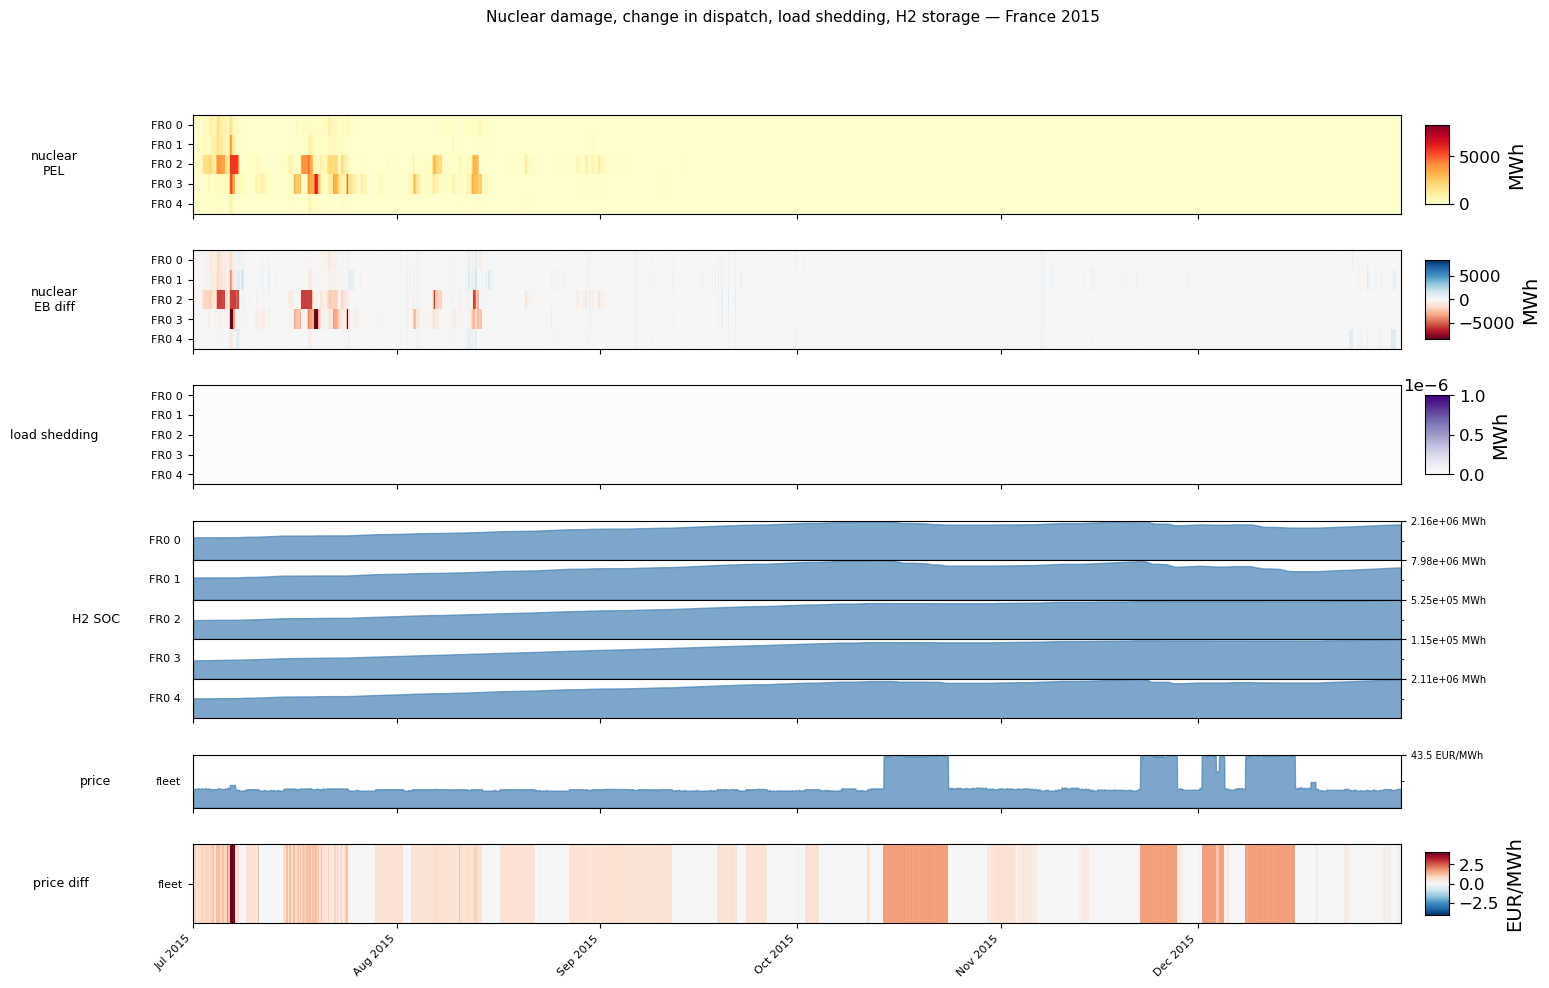

In [98]:
# ── Select year ───────────────────────────────────────────────────────────────
YEAR = 2015

networks = {label: pypsa.Network(path) for label, path in _network_paths(YEAR).items()}
nc = NetworkCollection(list(networks.values()), index=list(networks.keys()))

base = "base_dis"
scen = "dis"

# ── Statistics diffs ──────────────────────────────────────────────────────────
ts_diff = format_ts_diff_df(networks, stat="energy_balance", base=base)

# ── Load shedding ─────────────────────────────────────────────────────────────
EXCLUDE_gen_storage = ["coal", "ocgt", "ccgt"]
ts_eb  = format_ts_df(networks[scen], stat="energy_balance")
ts_eb  = ts_eb[~ts_eb["carrier"].isin(EXCLUDE_gen_storage)]
ls_raw = ts_eb[
    (ts_eb["carrier"] == "load_shedding") &
    (ts_eb["bus_carrier"] == "AC")
]
ls_df = ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum").fillna(0)
ls_df[ls_df < 0.001] = 0

# ── Nuclear PEL ───────────────────────────────────────────────────────────────
_s = scenarios_dis[YEAR]
pel_dict_nuc = {
    "nuclear": compute_potential_energy_loss_nuclear(
        _s["damage_df"], _s["powerplants_df"],
        freq="h", granularity="bus",
    )
}

storage_dict = build_storage_dict(nc, scen)

def fleet_price(n):
    ac      = n.buses.index[n.buses.carrier == "AC"]
    prices  = n.buses_t.marginal_price[ac]
    load_w  = n.loads_t.p_set.reindex(columns=ac).fillna(0)
    return (prices * load_w).sum(axis=1) / load_w.sum(axis=1).replace(0, np.nan)

price_base = fleet_price(networks[base])
price_dis  = fleet_price(networks[scen])
price_diff = (price_dis - price_base).to_frame("fleet")
price_base = fleet_price(networks[base]).to_frame("fleet")
# price_diff_clipped = price_diff.clip(lower=-200, upper=20)


# ── Fleet price (load-weighted average across AC buses) ───────────────────────
_n          = networks[scen]
_ac         = _n.buses.index[_n.buses.carrier == "AC"]
_prices     = _n.buses_t.marginal_price[_ac]
_load_w  = _n.loads_t.p_set.reindex(columns=_ac).fillna(0)   # (time × bus)
price_fleet = ((_prices * _load_w).sum(axis=1) / _load_w.sum(axis=1).replace(0, np.nan)).to_frame("fleet")



# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plot_combination_profile(
    carrier_groups={"nuclear": "nuclear"},
    components={
        "PEL": {
            "type": "carrier_dict", "data": pel_dict_nuc,
            "cmap": "YlOrRd", "unit": "MWh", "vmax_group": "nuclear",
        },
        "EB diff": {
            "type": "ts_diff", "data": ts_diff, "network": scen,
            "cmap": "RdBu", "symmetric": True, "unit": "MWh", "vmax_group": "nuclear",
        },
        "load shedding": {
            "type": "direct", "data": ls_df,
            "cmap": "Purples", "unit": "MWh",
        },
        "H2 SOC": {
            "type": "direct", "data": storage_dict["H2"],
            "render": "area",
            "unit": "MWh",
            "row_height": 0.6,
        },
        "price": {
            "type": "direct", "data": price_fleet,
            "render": "area", "unit": "EUR/MWh",
            "row_height": 0.8,
        },
        "price diff": {
            "type": "direct", "data": price_diff,
            "render": "heatmap",
            "cmap": "RdBu_r",
            "symmetric": True,
            "unit": "EUR/MWh",
            "row_height": 1.2,
        },

    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-07-01", f"{YEAR}-12-31"),
    title=f"Nuclear damage, change in dispatch, load shedding, H2 storage — France {YEAR}",
)


<Axes: xlabel='snapshot'>

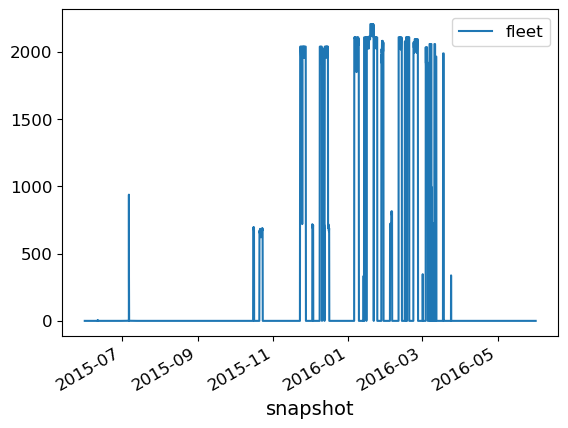

In [245]:
price_diff.plot()

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current:

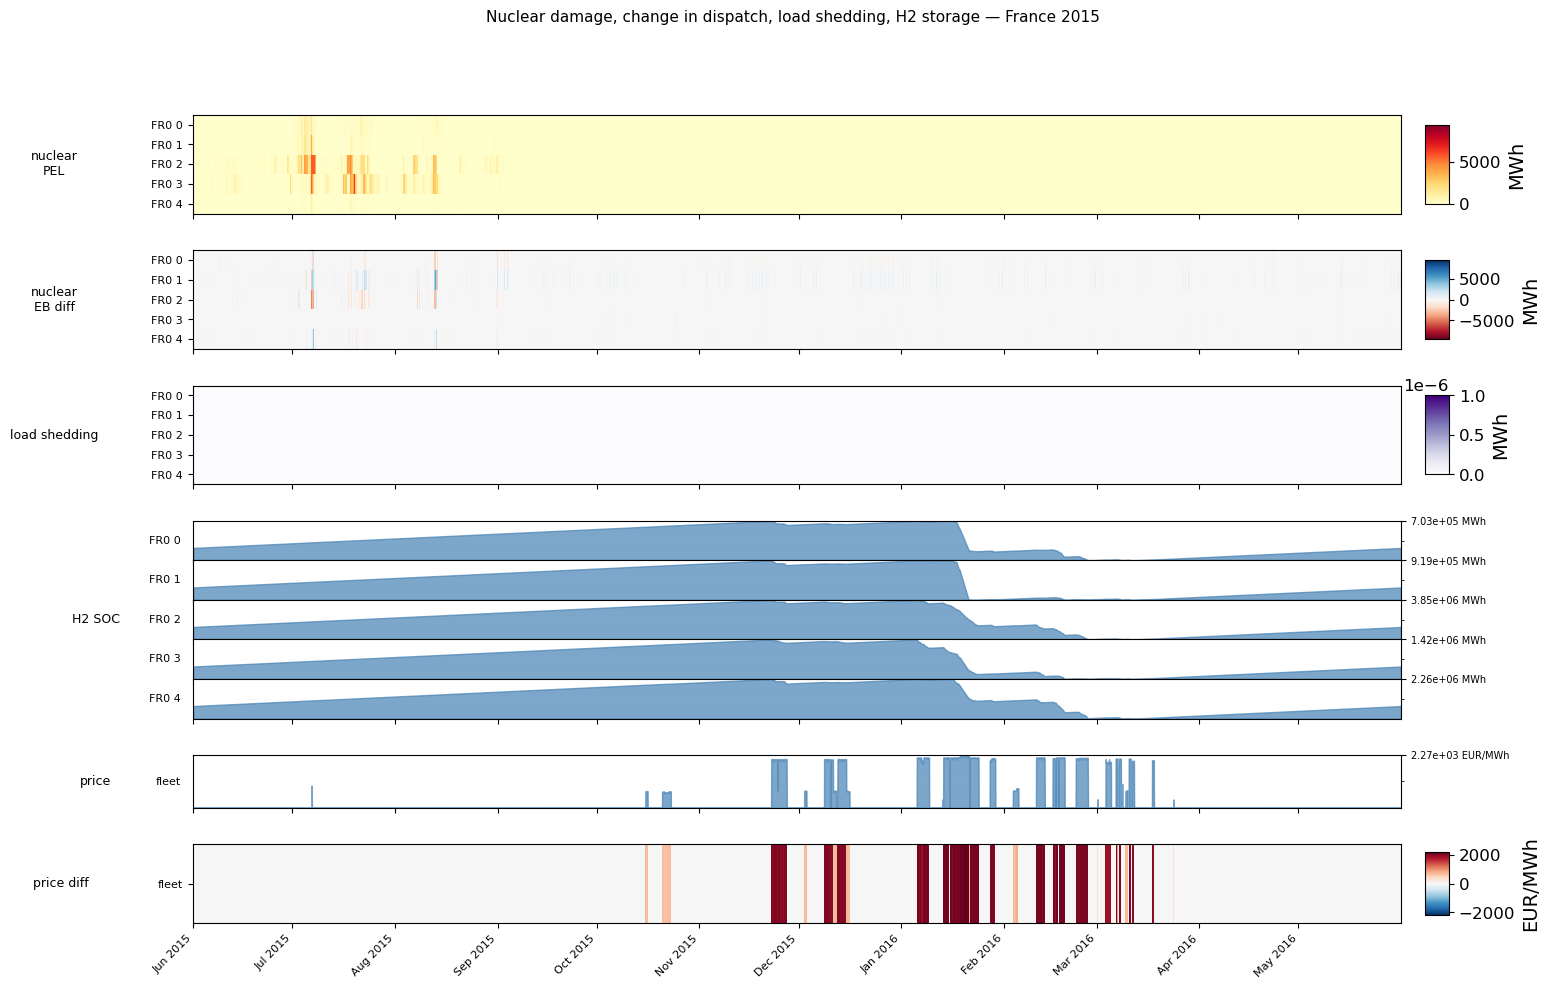

In [247]:
# ── Select year ───────────────────────────────────────────────────────────────
YEAR = 2015

networks = {label: pypsa.Network(path) for label, path in _network_paths(YEAR).items()}
nc = NetworkCollection(list(networks.values()), index=list(networks.keys()))

base = "base_dis"
scen = "dis"

# ── Statistics diffs ──────────────────────────────────────────────────────────
ts_diff = format_ts_diff_df(networks, stat="energy_balance", base=base)

# ── Load shedding ─────────────────────────────────────────────────────────────
EXCLUDE_gen_storage = ["coal", "ocgt", "ccgt"]
ts_eb  = format_ts_df(networks[scen], stat="energy_balance")
ts_eb  = ts_eb[~ts_eb["carrier"].isin(EXCLUDE_gen_storage)]
ls_raw = ts_eb[
    (ts_eb["carrier"] == "load_shedding") &
    (ts_eb["bus_carrier"] == "AC")
]
ls_df = ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum").fillna(0)
ls_df[ls_df < 0.01] = 0

# ── Nuclear PEL ───────────────────────────────────────────────────────────────
_s = scenarios_dis[YEAR]
pel_dict_nuc = {
    "nuclear": compute_potential_energy_loss_nuclear(
        _s["damage_df"], _s["powerplants_df"],
        freq="h", granularity="bus",
    )
}

storage_dict = build_storage_dict(nc, scen)

# ── Prices ────────────────────────────────────────────────────────────────────
def fleet_price(n):
    ac     = n.buses.index[n.buses.carrier == "AC"]
    prices = n.buses_t.marginal_price[ac]
    load_w = n.loads_t.p_set.reindex(columns=ac).fillna(0)
    return (prices * load_w).sum(axis=1) / load_w.sum(axis=1).replace(0, np.nan)

price_base  = fleet_price(networks[base])
price_dis   = fleet_price(networks[scen])
price_fleet = price_dis.to_frame("fleet")
price_diff  = (price_dis - price_base).to_frame("fleet")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plot_combination_profile(
    carrier_groups={"nuclear": "nuclear"},
    components={
        "PEL": {
            "type": "carrier_dict", "data": pel_dict_nuc,
            "cmap": "YlOrRd", "unit": "MWh", "vmax_group": "nuclear",
        },
        "EB diff": {
            "type": "ts_diff", "data": ts_diff, "network": scen,
            "cmap": "RdBu", "symmetric": True, "unit": "MWh", "vmax_group": "nuclear",
        },
        "load shedding": {
            "type": "direct", "data": ls_df,
            "cmap": "Purples", "unit": "MWh",
        },
        "H2 SOC": {
            "type": "direct", "data": storage_dict["H2"],
            "render": "area", "unit": "MWh", "row_height": 0.6,
        },
        "price": {
            "type": "direct", "data": price_fleet,
            "render": "area", "unit": "EUR/MWh", "row_height": 0.8,
        },
        "price diff": {
            "type": "direct", "data": price_diff,
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-06-01", f"{YEAR+1}-05-31"),
    title=f"Nuclear damage, change in dispatch, load shedding, H2 storage — France {YEAR}",
)


<Axes: xlabel='snapshot'>

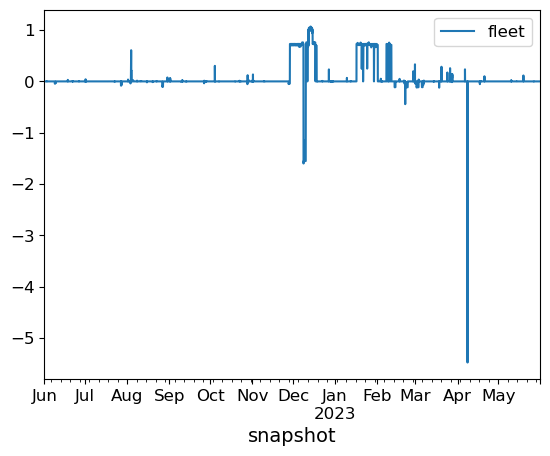

In [239]:
price_diff.plot()

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


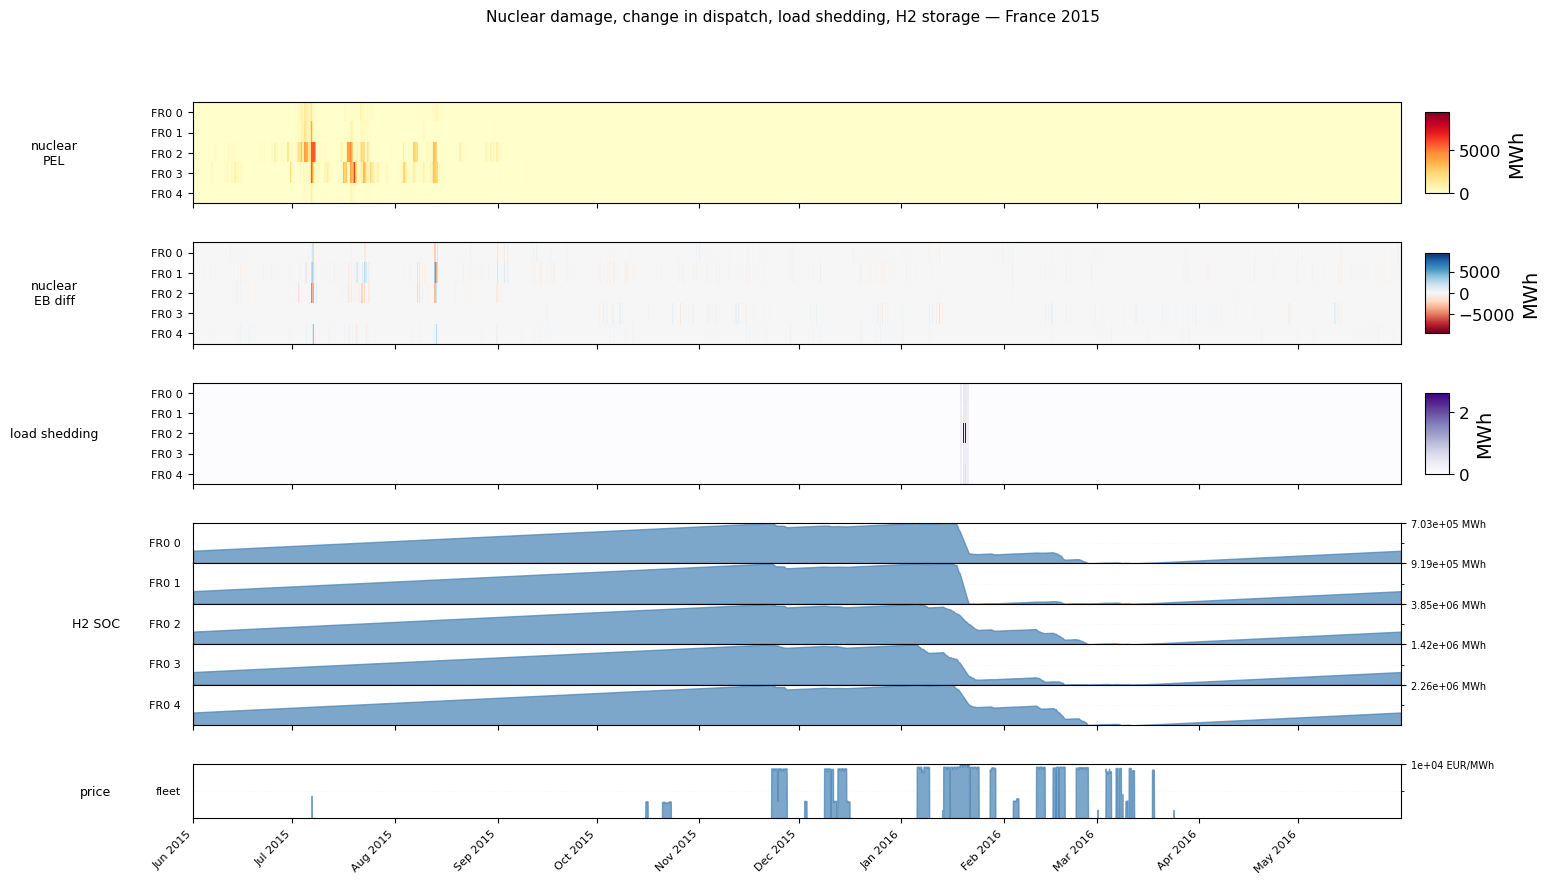

In [160]:
# ── Select year ───────────────────────────────────────────────────────────────
YEAR = 2015

networks = {label: pypsa.Network(path) for label, path in _network_paths(YEAR).items()}
nc = NetworkCollection(list(networks.values()), index=list(networks.keys()))

base = "base"
scen = "dis"

# ── Statistics diffs ──────────────────────────────────────────────────────────
ts_diff = format_ts_diff_df(networks, stat="energy_balance", base=base)

# ── Load shedding ─────────────────────────────────────────────────────────────
EXCLUDE_gen_storage = ["coal", "ocgt", "ccgt"]
ts_eb  = format_ts_df(networks[scen], stat="energy_balance")
ts_eb  = ts_eb[~ts_eb["carrier"].isin(EXCLUDE_gen_storage)]
ls_raw = ts_eb[
    (ts_eb["carrier"] == "load_shedding") &
    (ts_eb["bus_carrier"] == "AC")
]
ls_df = ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum").fillna(0)
ls_df[ls_df < 0.01] = 0

# ── Nuclear PEL ───────────────────────────────────────────────────────────────
_s = scenarios_dis[YEAR]
pel_dict_nuc = {
    "nuclear": compute_potential_energy_loss_nuclear(
        _s["damage_df"], _s["powerplants_df"],
        freq="h", granularity="bus",
    )
}

storage_dict = build_storage_dict(nc, scen)

# ── Fleet price (load-weighted average across AC buses) ───────────────────────
_n          = networks[scen]
_ac         = _n.buses.index[_n.buses.carrier == "AC"]
_prices     = _n.buses_t.marginal_price[_ac]
_load_w  = _n.loads_t.p_set.reindex(columns=_ac).fillna(0)   # (time × bus)
price_fleet = ((_prices * _load_w).sum(axis=1) / _load_w.sum(axis=1).replace(0, np.nan)).to_frame("fleet")



# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plot_combination_profile(
    carrier_groups={"nuclear": "nuclear"},
    components={
        "PEL": {
            "type": "carrier_dict", "data": pel_dict_nuc,
            "cmap": "YlOrRd", "unit": "MWh", "vmax_group": "nuclear",
        },
        "EB diff": {
            "type": "ts_diff", "data": ts_diff, "network": scen,
            "cmap": "RdBu", "symmetric": True, "unit": "MWh", "vmax_group": "nuclear",
        },
        "load shedding": {
            "type": "direct", "data": ls_df,
            "cmap": "Purples", "unit": "MWh",
        },
        "H2 SOC": {
            "type": "direct", "data": storage_dict["H2"],
            "render": "area",
            "unit": "MWh",
            "row_height": 0.6,
        },
        "price": {
            "type": "direct", "data": price_fleet,
            "render": "area", "unit": "EUR/MWh",
            "row_height": 0.8,
        },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-06-01", f"{YEAR+1}-05-31"),
    title=f"Nuclear damage, change in dispatch, load shedding, H2 storage — France {YEAR}",
)


(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Installed Capacity (MW)'>])

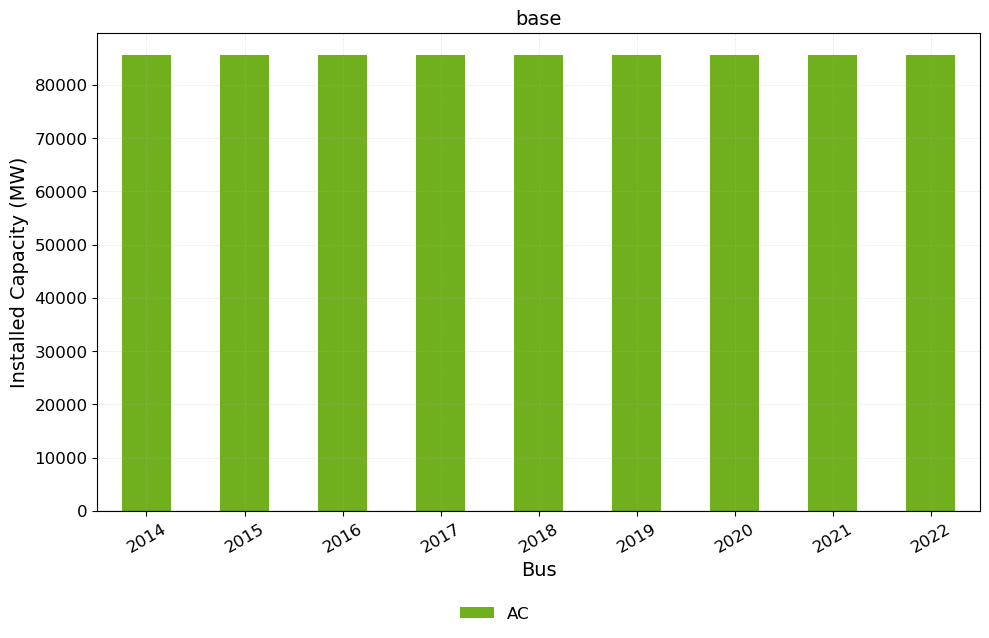

In [66]:
diff_plot = diff_multi[
    diff_multi["techgroup"].isin(["Line", "Link"])
    & (diff_multi["tech"] != "H2 electrolysis")
    & (diff_multi["bus_carrier"] == "AC")
    & (diff_multi["network"] == "base")
].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)

plot_stats_bar(diff_plot, column="installed capacity", networks=["base"],
               multiplier=1, title="Installed Capacity (MW)", color_map=color_map, figsize=(10, 6))



TypeError: no numeric data to plot

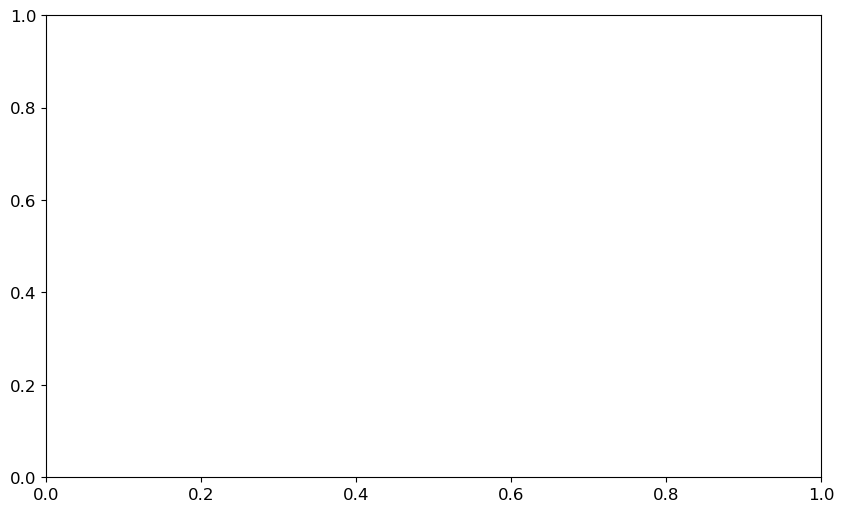

In [67]:
diff_plot = diff_multi[
    diff_multi["techgroup"].isin(["Line", "Link"])
    & (diff_multi["tech"] != "H2 electrolysis")
    & (diff_multi["bus_carrier"] == "AC")
    & (diff_multi["network"] == "base")
].copy()
diff_plot["bus"] = diff_plot["year"].astype(str)

plot_stats_bar(diff_plot, column="expanded capacity", networks=["base"],
               multiplier=1, title="Expanded Capacity (MW)", color_map=color_map, figsize=(10, 6))



(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='Optimal Capacity Diff (GW)'>])

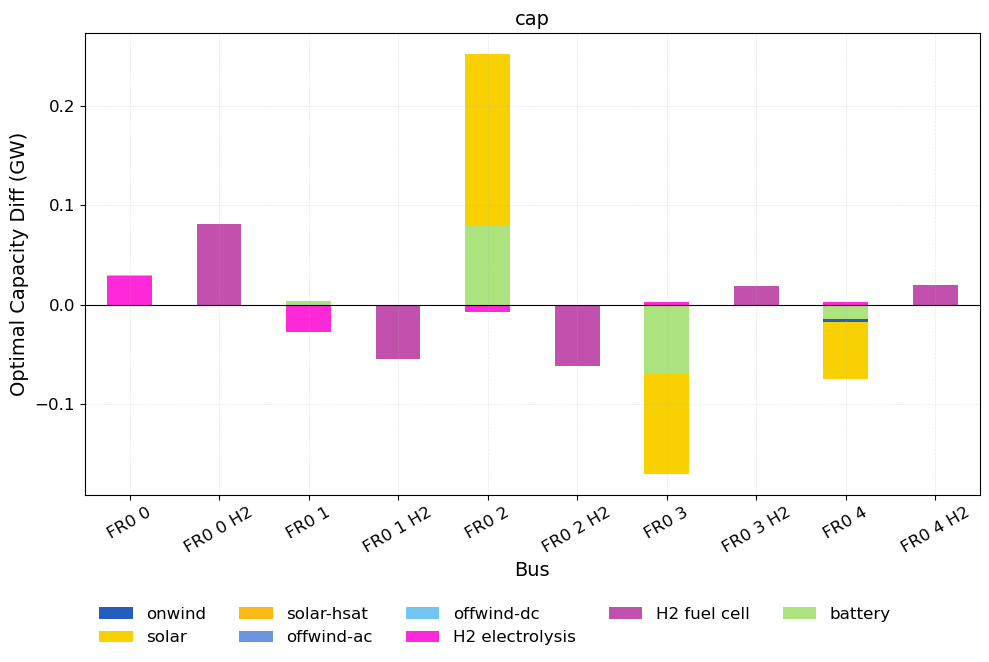

In [ ]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal_capacity_diff",
    multiplier=1e-3,
    title="Optimal Capacity Diff (GW)",
    networks=["cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

In [222]:
# ── hourly prices per year (load-weighted average across AC buses) ────────────
prices_by_year = {}
for year, path in DIS_NETWORK_PATHS.items():
    n       = pypsa.Network(path)
    ac_buses = n.buses.index[n.buses.carrier == "AC"]
    prices  = n.buses_t.marginal_price[ac_buses]
    load_w  = n.loads_t.p_set.mean().reindex(ac_buses).fillna(0)
    prices_by_year[year] = prices.mul(load_w, axis=1).sum(axis=1) / load_w.sum()

prices_df = pd.DataFrame(prices_by_year)   # (time × year)


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current:

<Axes: xlabel='snapshot'>

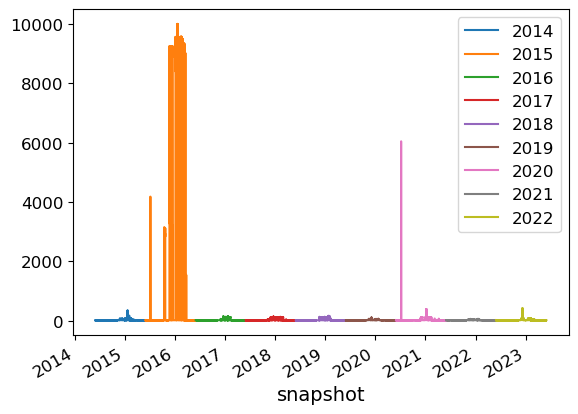

In [152]:
prices_df.plot()

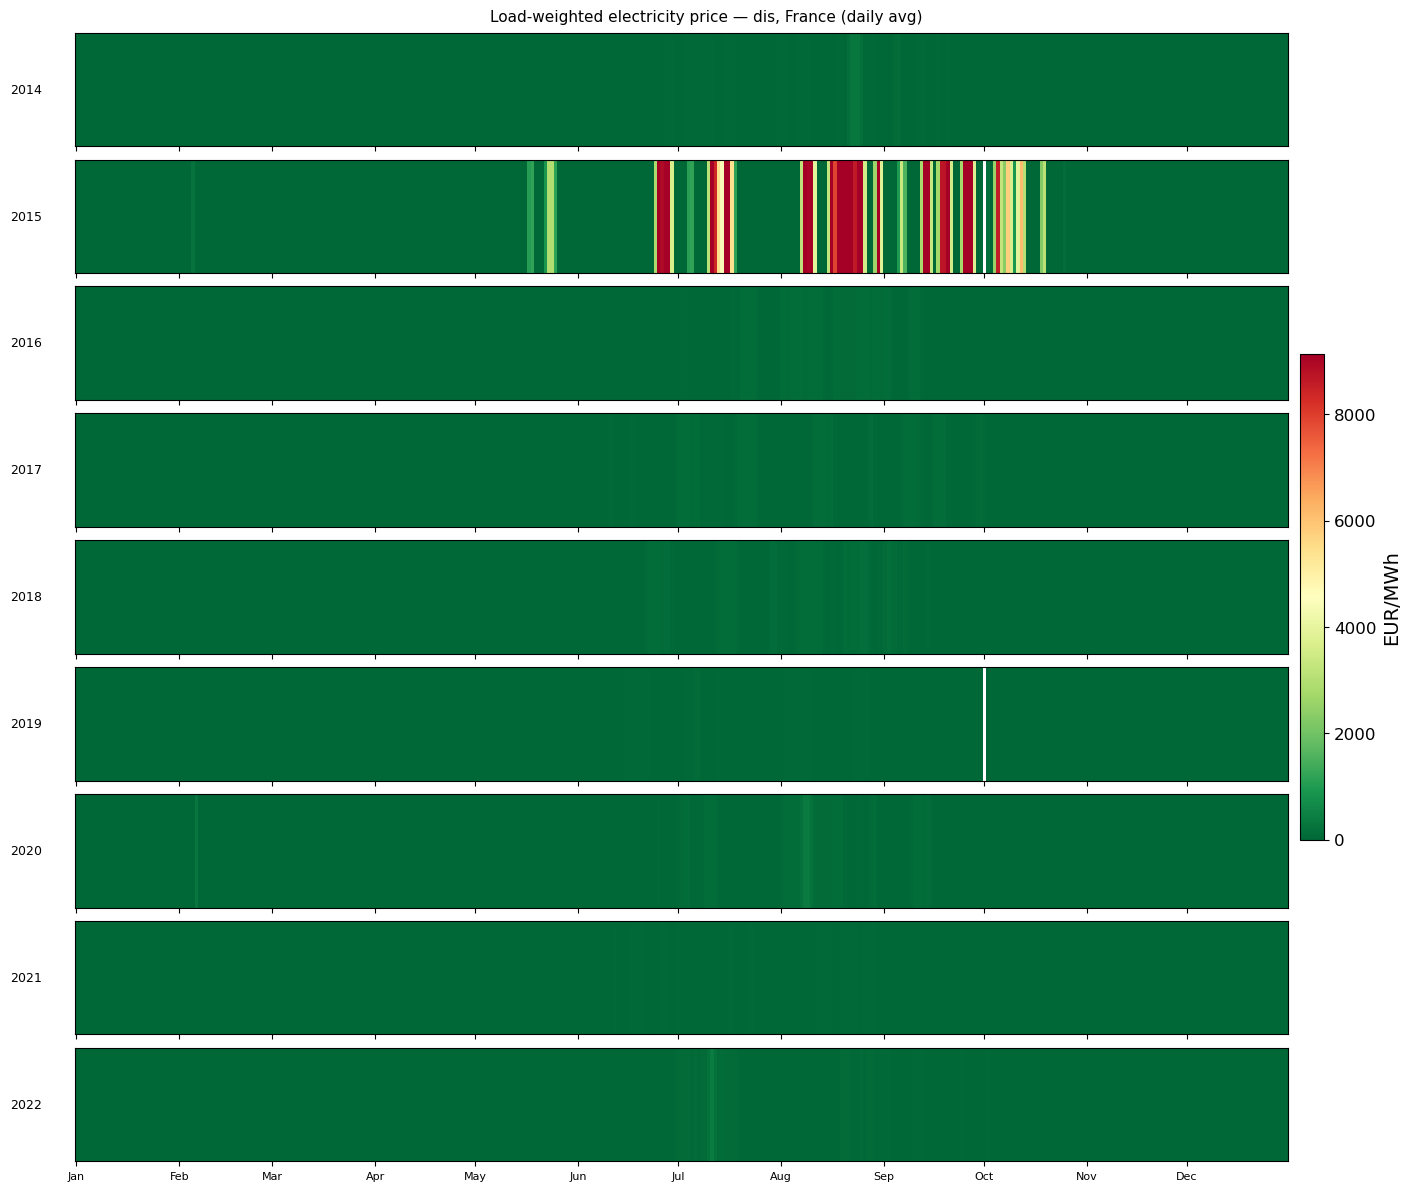

In [154]:
fig, axes = plt.subplots(
    len(YEARS), 1,
    figsize=(14, len(YEARS) * 1.2 + 1),
    sharex=True,
    constrained_layout=True,
)

vmax = np.percentile(
    [v for s in prices_by_year.values() for v in s.dropna()], 99
)

for ax, (year, series) in zip(axes, sorted(prices_by_year.items())):
    daily = series.resample("D").mean()
    daily.index = daily.index.day_of_year
    ax.imshow(daily.values[np.newaxis, :], aspect="auto", cmap="RdYlGn_r",
              interpolation="nearest",
              norm=plt.Normalize(vmin=0, vmax=vmax))
    ax.set_yticks([])
    ax.set_ylabel(str(year), fontsize=9, rotation=0, labelpad=35, va="center")

month_starts = pd.date_range("2001-01-01", "2001-12-01", freq="MS").day_of_year - 1
month_labels = pd.date_range("2001-01-01", "2001-12-01", freq="MS").strftime("%b")
axes[-1].set_xticks(month_starts)
axes[-1].set_xticklabels(month_labels, fontsize=8)

fig.colorbar(
    plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(vmin=0, vmax=vmax)),
    ax=axes, label="EUR/MWh", fraction=0.02, pad=0.01,
)
fig.suptitle("Load-weighted electricity price — dis, France (daily avg)", fontsize=11)
plt.show()


In [ ]:
# ── per-bus price heatmap (one row per year, buses on y-axis) ─────────────────
prices_by_year_bus = {}
for year, path in DIS_NETWORK_PATHS.items():
    n        = pypsa.Network(path)
    ac_buses = n.buses.index[n.buses.carrier == "AC"]
    prices_by_year_bus[year] = n.buses_t.marginal_price[ac_buses]

# Build (bus × doy) daily-average matrix for each year
def _to_bus_doy(df):
    daily = df.resample("D").mean()
    daily.index = daily.index.day_of_year
    return daily.T   # (bus × doy)

bus_doy = {yr: _to_bus_doy(df) for yr, df in sorted(prices_by_year_bus.items())}

# Shared colour scale (99th percentile across all years/buses)
vmax_bus = np.percentile(
    [v for df in bus_doy.values() for v in df.values.ravel() if not np.isnan(v)], 99
)
norm_bus = plt.Normalize(vmin=0, vmax=vmax_bus)
cmap_bus = "RdYlGn_r"

n_buses = next(iter(bus_doy.values())).shape[0]
row_h   = max(0.6, 4.0 / n_buses)   # scale row height with bus count

fig, axes = plt.subplots(
    len(YEARS), 1,
    figsize=(14, len(YEARS) * n_buses * row_h + 1),
    sharex=True,
    constrained_layout=True,
)
if len(YEARS) == 1:
    axes = [axes]

for ax, (year, mat) in zip(axes, bus_doy.items()):
    im = ax.imshow(mat.values, aspect="auto", cmap=cmap_bus,
                   interpolation="nearest", norm=norm_bus)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=7)
    ax.set_ylabel(str(year), fontsize=9, rotation=0, labelpad=55, va="center")

month_starts = pd.date_range("2001-01-01", "2001-12-01", freq="MS").day_of_year - 1
month_labels = pd.date_range("2001-01-01", "2001-12-01", freq="MS").strftime("%b")
axes[-1].set_xticks(month_starts)
axes[-1].set_xticklabels(month_labels, fontsize=8)

fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_bus, norm=norm_bus),
    ax=axes, label="EUR/MWh", fraction=0.02, pad=0.01,
)
fig.suptitle("Electricity price by bus — dis, France (daily avg)", fontsize=11)
plt.show()
